Investigating the historical and future behavior of maximum and minimum temperatures and rainfall in India

In [4]:
#pip install imdlib
import imdlib as imd
import geopandas as gpd
import numpy as np             
import pandas as pd             
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
# loading grid data
data_tmin = imd.open_data('tmin', 1951, 2024, fn_format='yearwise')
data_tmax = imd.open_data('tmax', 1951, 2024, fn_format='yearwise')
data_rain = imd.open_data('rain', 1951, 2024, fn_format='yearwise')

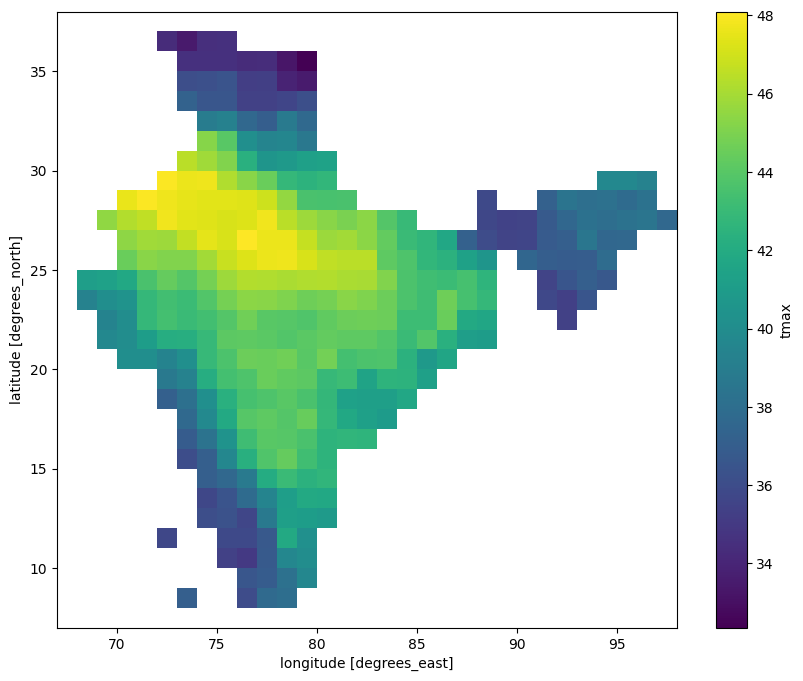

In [6]:
imd_r = imd.open_data('tmax', 2022, 2024, 'yearwise')  # (variable, start_yr, end_yr, fn_format='daywise')
imd_ra = imd_r.get_xarray()
imd_rai = imd_ra.where(imd_ra['tmax'] < 90)  # Remove NaN values
imd_rain = imd_rai['tmax'].max('time')
imd_rain.plot(figsize=(10, 8))

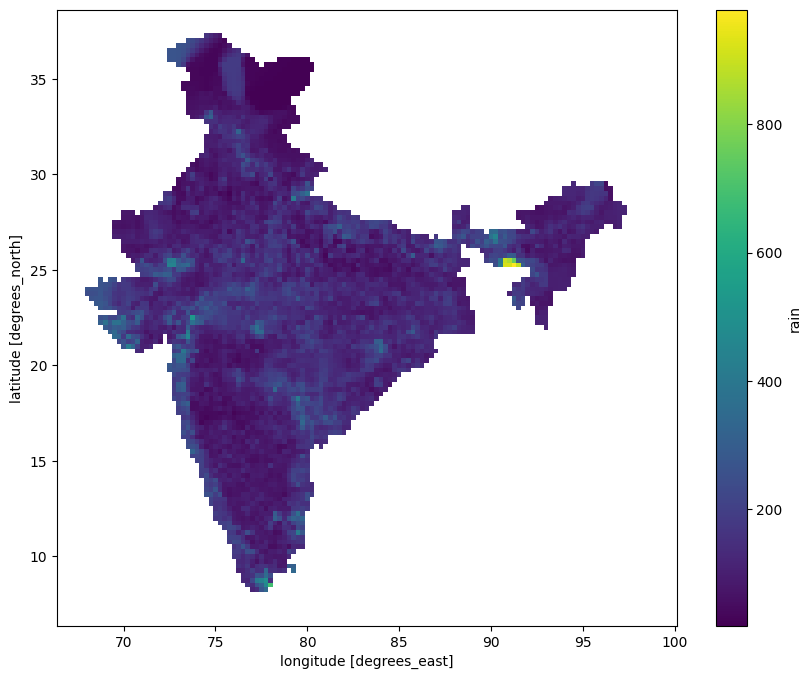

In [4]:
imd_r = imd.open_data('rain', 2022, 2024,'yearwise') # (variable, start_yr, end_yr, fn_format='yearwise')
imd_ra = imd_r.get_xarray()
imd_rai = imd_ra.where(imd_ra['rain'] != -999.) #Remove NaN values
imd_rain = imd_rai['rain'].max('time')
imd_rain.plot(figsize=(10, 8))

In [7]:
# choose (assine lat & lon)  # https://power.larc.nasa.gov/data-access-viewer/

lat = 18.52
lon = 73.84

In [8]:
# tmin

file_dir='co_test'
data_tmin.to_csv('coordinate_tmin.csv', lat, lon, file_dir)  # This downloads the file

# Construct the filename based on latitude and longitude
file_name = f'coordinate_tmin_{lat:.2f}_{lon:.2f}.csv'
    
# Read the temperature data from the file
tmin = pd.read_csv(f'{file_dir}/{file_name}')
    
# Convert the 'DateTime' column to a DatetimeIndex
tmin['DateTime'] = pd.to_datetime(tmin['DateTime'])
    
# Use the lat/lon combination for the correct column name in the CSV
col_name = f'{lat} {lon}'
    
# Create a DataFrame with DateTime as index and temperature as 'temp' column
tmin = pd.DataFrame(list(tmin[col_name]), index=tmin['DateTime'], columns=['tmin'])


# tmax

file_dir='co_test'
data_tmax.to_csv('coordinate_tmax.csv', lat, lon, file_dir)  # This downloads the file

# Construct the filename based on latitude and longitude
file_name = f'coordinate_tmax_{lat:.2f}_{lon:.2f}.csv'
    
# Read the temperature data from the file
tmax = pd.read_csv(f'{file_dir}/{file_name}')
    
# Convert the 'DateTime' column to a DatetimeIndex
tmax['DateTime'] = pd.to_datetime(tmax['DateTime'])
    
# Use the lat/lon combination for the correct column name in the CSV
col_name = f'{lat} {lon}'
    
# Create a DataFrame with DateTime as index and maximum temperature of day as 'tmax' column
tmax = pd.DataFrame(list(tmax[col_name]), index=tmax['DateTime'], columns=['tmax'])


# rain

file_dir='co_test'
data_rain.to_csv('coordinate_rain.csv', lat, lon, file_dir)  # This downloads the file

# Construct the filename based on latitude and longitude
file_name = f'coordinate_rain_{lat:.2f}_{lon:.2f}.csv'
    
# Read the temperature data from the file
rain = pd.read_csv(f'{file_dir}/{file_name}')
    
# Convert the 'DateTime' column to a DatetimeIndex
rain['DateTime'] = pd.to_datetime(rain['DateTime'])
    
# Use the lat/lon combination for the correct column name in the CSV
col_name = f'{lat} {lon}'
    
# Create a DataFrame with DateTime as index and rain of a day as 'rain' column
rain = pd.DataFrame(list(rain[col_name]), index=rain['DateTime'], columns=['rain'])


# merge all data(tmin, tmax, rain) of given assine lat & lon
df = pd.concat([tmin, tmax, rain], axis=1)
df

,tmin,tmax,rain
DateTime,,,
1951-01-01,17.2500,28.0900,0.0000
1951-01-02,16.7200,28.6300,0.0000
1951-01-03,15.4700,29.1600,0.0000
1951-01-04,15.4300,29.0200,0.0000
1951-01-05,15.0100,28.7700,0.0000
...,...,...,...
2024-12-27,19.5976,28.9455,0.0000
2024-12-28,19.9826,29.9912,0.0000
2024-12-29,19.7765,30.4973,5.8349


In [9]:
# Basic statistics
print("Basic Statistics for assigned lat & lon:")
df.describe() #statistics

Basic Statistics for assigned lat & lon:


,tmin,tmax,rain
count,27029.000000,27029.000000,27029.000000
mean,20.460708,31.098057,2.789134
std,3.177486,2.855360,10.819182
min,8.600000,22.984800,0.000000
25%,17.960000,28.930000,0.000000
50%,21.580000,30.820000,0.000000
75%,22.780000,33.290000,0.436400
max,27.700000,38.690000,349.079600


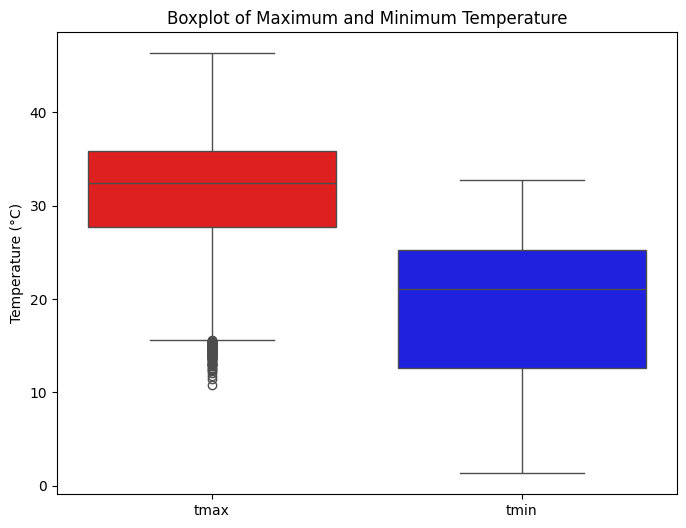

In [8]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df[['tmax', 'tmin']], palette=['red', 'blue'])
plt.ylabel('Temperature (°C)')
plt.title('Boxplot of Maximum and Minimum Temperature')
plt.show()

# Frequency

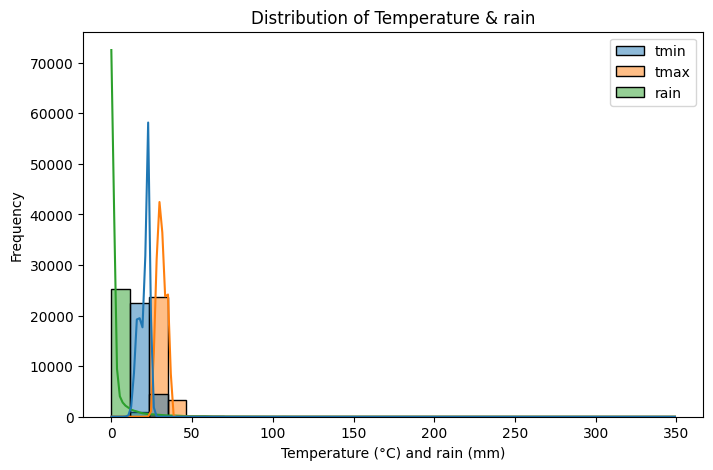

In [10]:
# Histogram for distribution
plt.figure(figsize=(8,5))
sns.histplot(df, bins=30, kde=True)
plt.xlabel('Temperature (°C) and rain (mm)')
plt.ylabel('Frequency')
plt.title('Distribution of Temperature & rain')
plt.show()

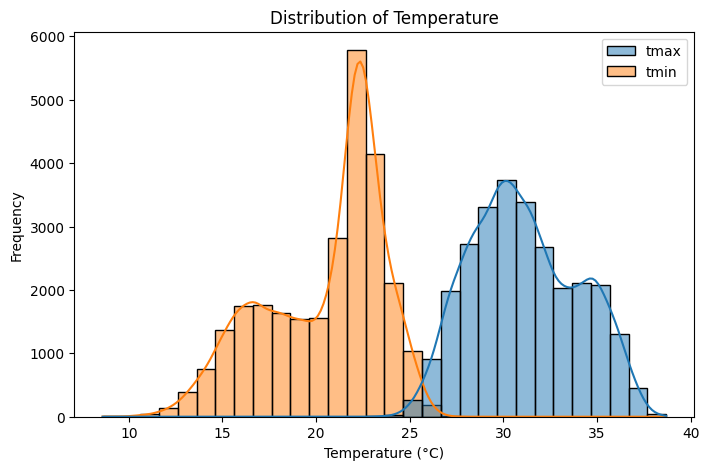

In [11]:
# Histogram for distribution
plt.figure(figsize=(8,5))
sns.histplot(df[['tmax', 'tmin']], bins=30, kde=True)
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Temperature')
plt.show()

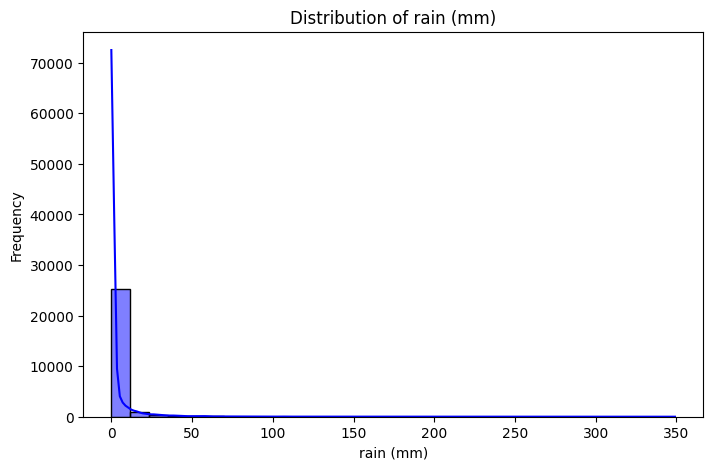

In [12]:
# Histogram for distribution
plt.figure(figsize=(8,5))
sns.histplot(df['rain'], bins=30, kde=True, color='blue')
plt.xlabel('rain (mm)')
plt.ylabel('Frequency')
plt.title('Distribution of rain (mm)')
plt.show()

# time series

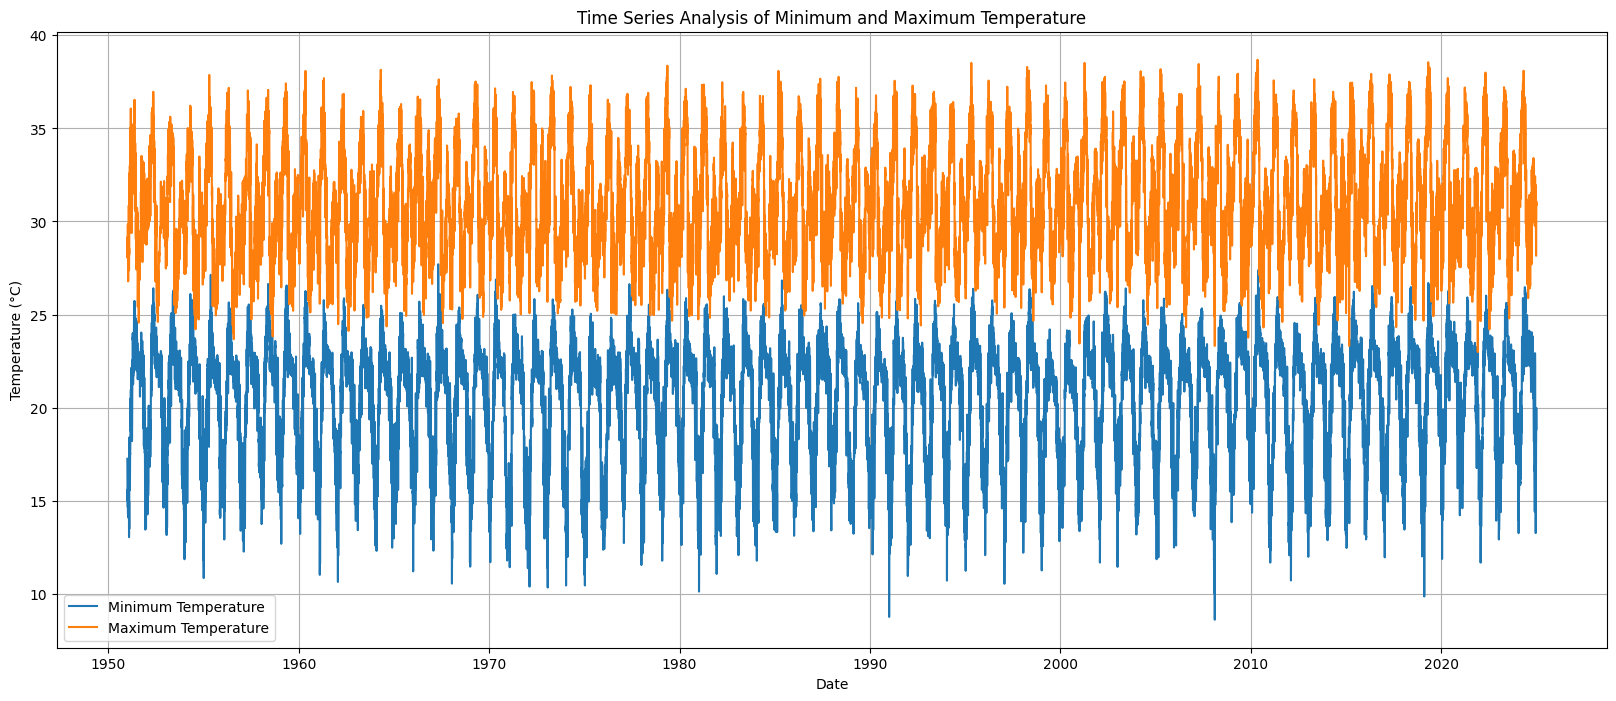

In [13]:
plt.figure(figsize=(20, 8))
plt.plot(tmin.index, tmin['tmin'], label='Minimum Temperature')
plt.plot(tmax.index, tmax['tmax'], label='Maximum Temperature')
plt.title('Time Series Analysis of Minimum and Maximum Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

# Analysis of tmin

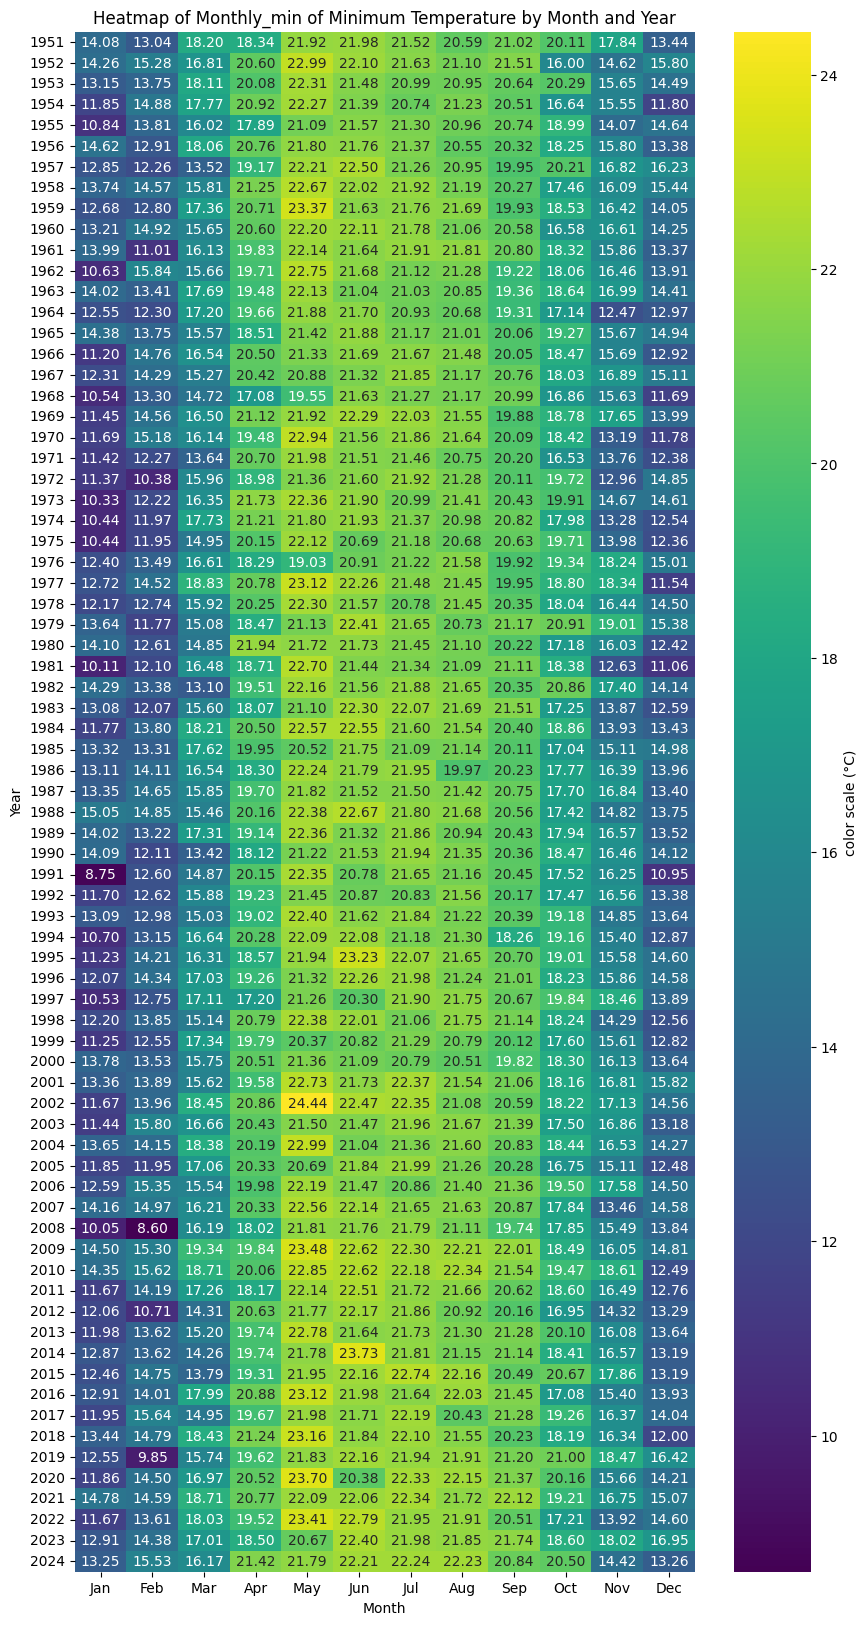

In [14]:
monthly_tmin = tmin.resample('ME').min()
monthly_tmin['Year'] = monthly_tmin.index.year
monthly_tmin['Month'] = monthly_tmin.index.month

# Pivot the data to create a matrix for the heatmap
heatmap_data = monthly_tmin.pivot(index="Year", columns="Month", values="tmin")

# Plot the heatmap
plt.figure(figsize=(10, 20))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'color scale (°C)'})
plt.title('Heatmap of Monthly_min of Minimum Temperature by Month and Year')

# Set x-axis labels to month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticklabels(month_names)

plt.xlabel('Month')
plt.ylabel('Year')
plt.yticks(rotation=0)
plt.show()

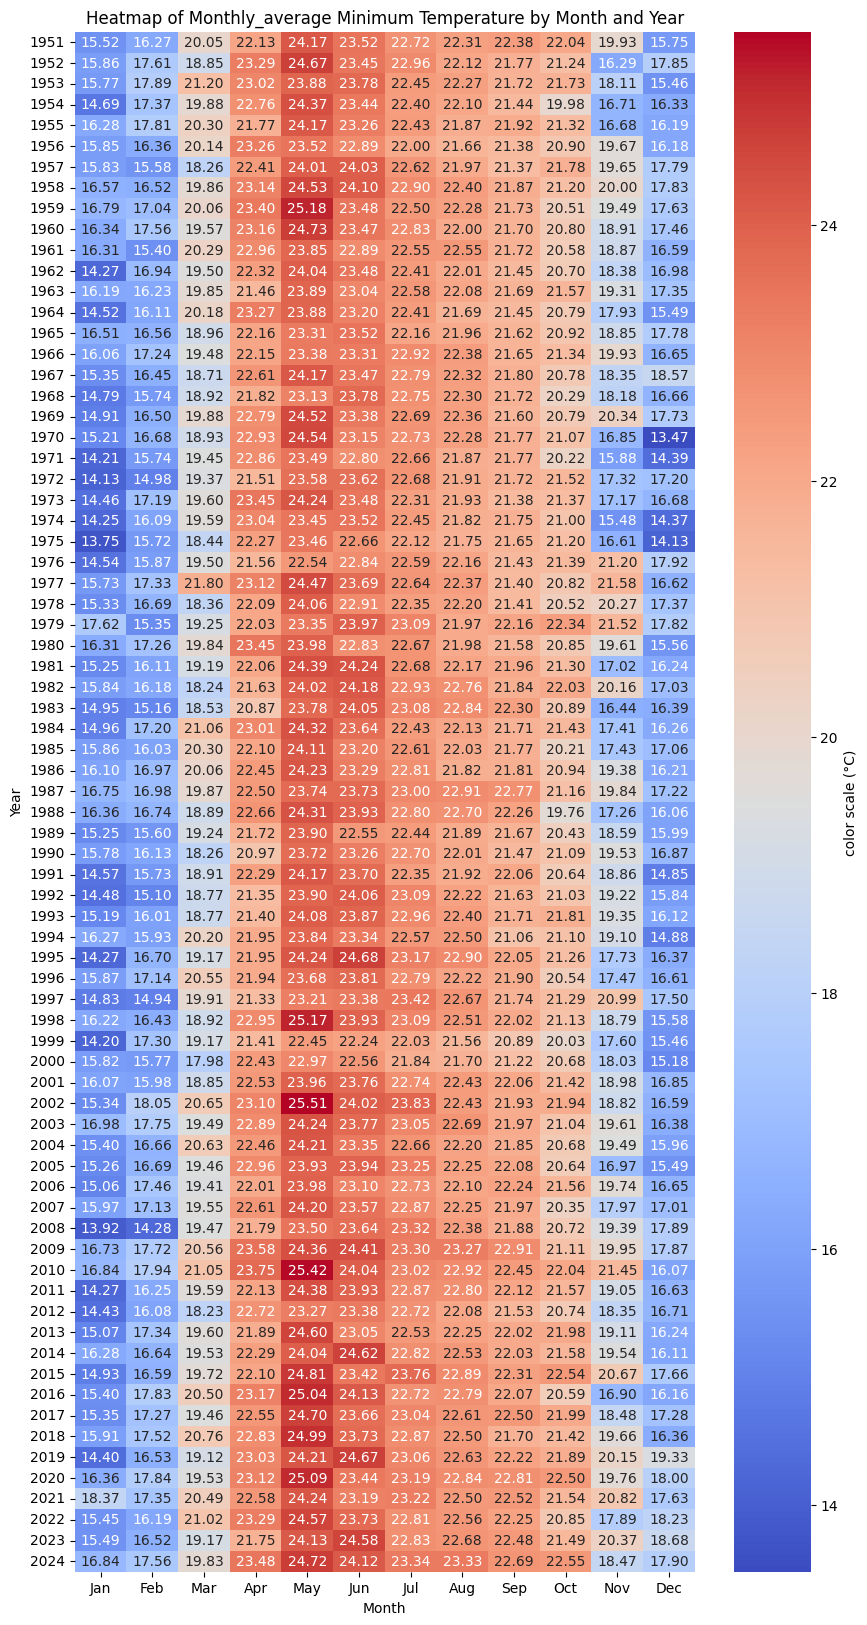

In [15]:
monthly_tmin = tmin.resample('ME').mean()
monthly_tmin['Year'] = monthly_tmin.index.year
monthly_tmin['Month'] = monthly_tmin.index.month

# Pivot the data to create a matrix for the heatmap
heatmap_data = monthly_tmin.pivot(index="Year", columns="Month", values="tmin")

# Plot the heatmap
plt.figure(figsize=(10, 20))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'color scale (°C)'})
plt.title('Heatmap of Monthly_average Minimum Temperature by Month and Year')

# Set x-axis labels to month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticklabels(month_names)

plt.xlabel('Month')
plt.ylabel('Year')
plt.yticks(rotation=0)
plt.show()

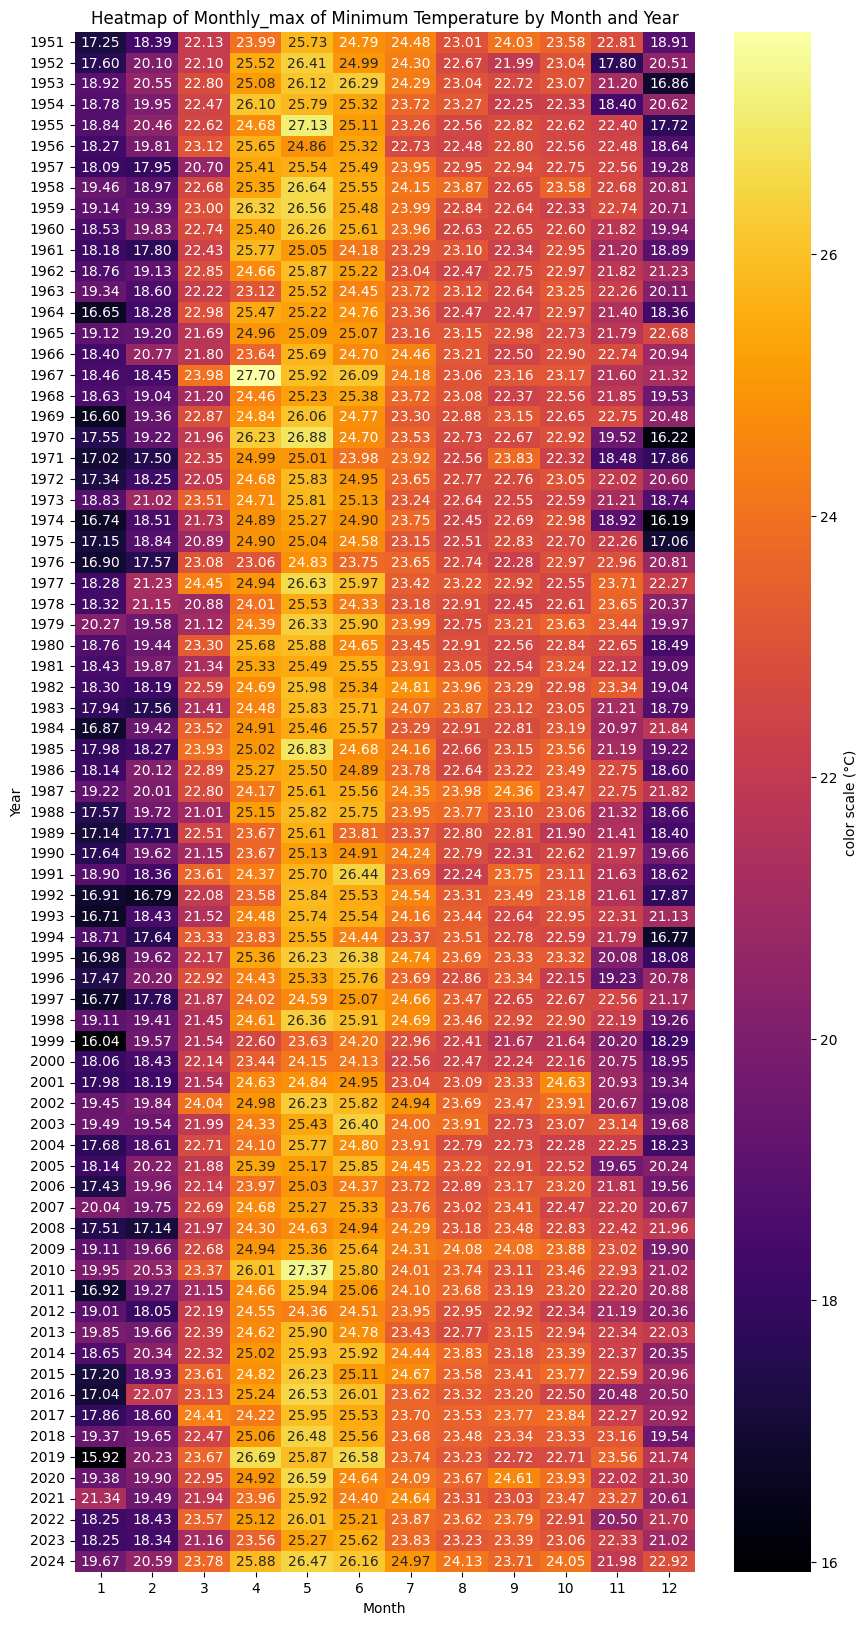

In [16]:
monthly_tmin = tmin.resample('ME').max()
monthly_tmin['Year'] = monthly_tmin.index.year
monthly_tmin['Month'] = monthly_tmin.index.month

# Pivot the data to create a matrix for the heatmap
heatmap_data = monthly_tmin.pivot(index="Year", columns="Month", values="tmin")

# Plot the heatmap
plt.figure(figsize=(10, 20))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="inferno", cbar_kws={'label': 'color scale (°C)'})
plt.title('Heatmap of Monthly_max of Minimum Temperature by Month and Year')

plt.xlabel('Month')
plt.ylabel('Year')
plt.yticks(rotation=0)
plt.show()

# Analysis of tmax

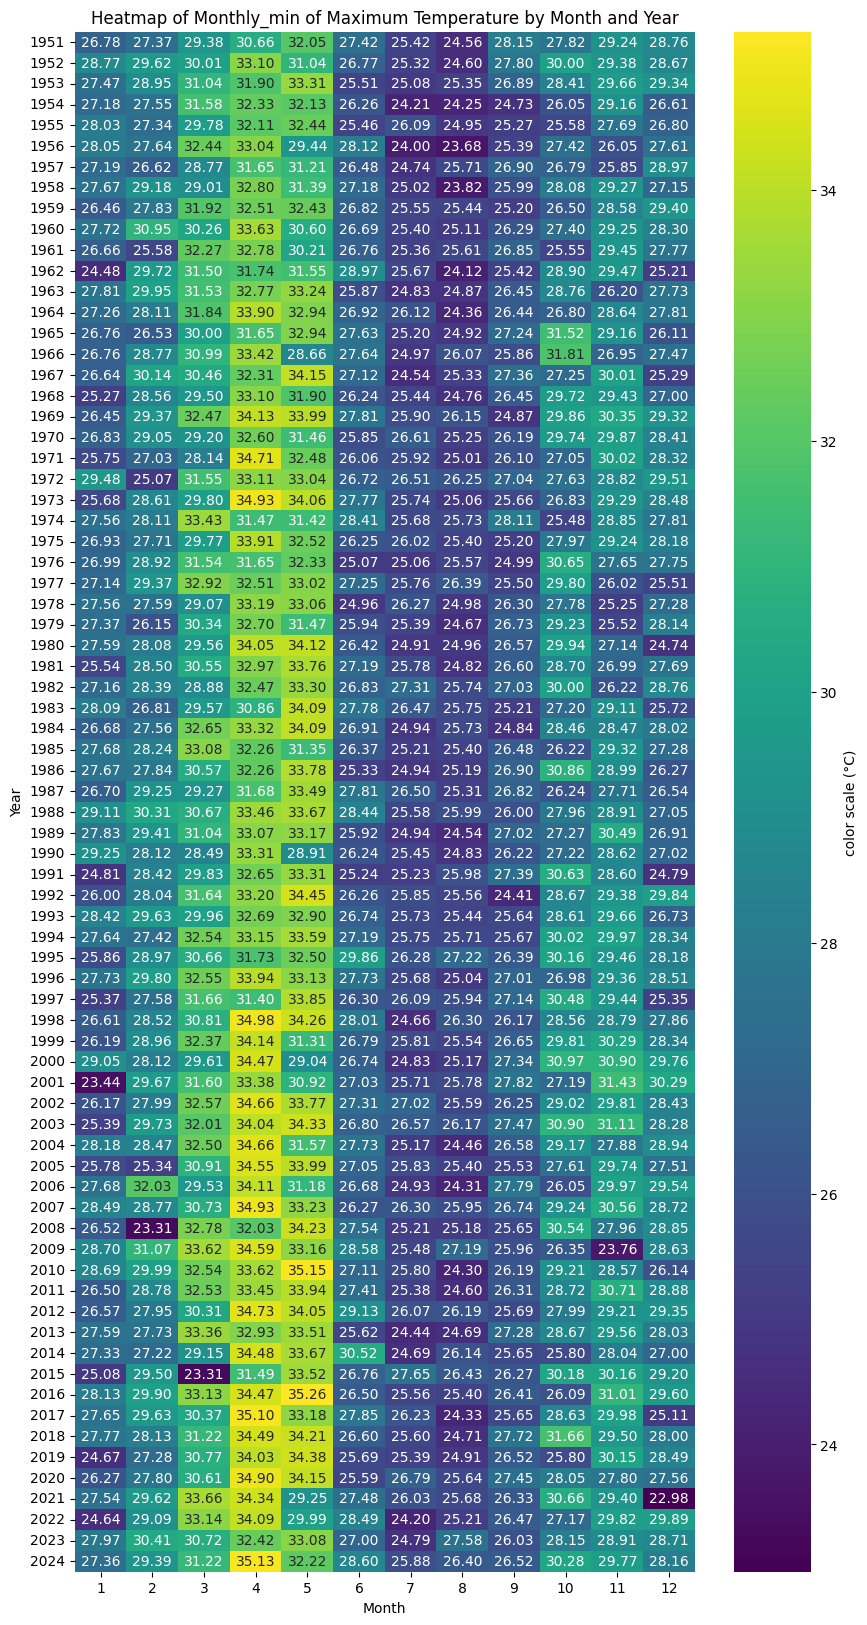

In [17]:
monthly_tmax = tmax.resample('ME').min()
monthly_tmax['Year'] = monthly_tmax.index.year
monthly_tmax['Month'] = monthly_tmax.index.month

# Pivot the data to create a matrix for the heatmap
heatmap_data = monthly_tmax.pivot(index="Year", columns="Month", values="tmax")

# Plot the heatmap
plt.figure(figsize=(10, 20))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'color scale (°C)'})
plt.title('Heatmap of Monthly_min of Maximum Temperature by Month and Year')

plt.xlabel('Month')
plt.ylabel('Year')
plt.yticks(rotation=0)
plt.show()

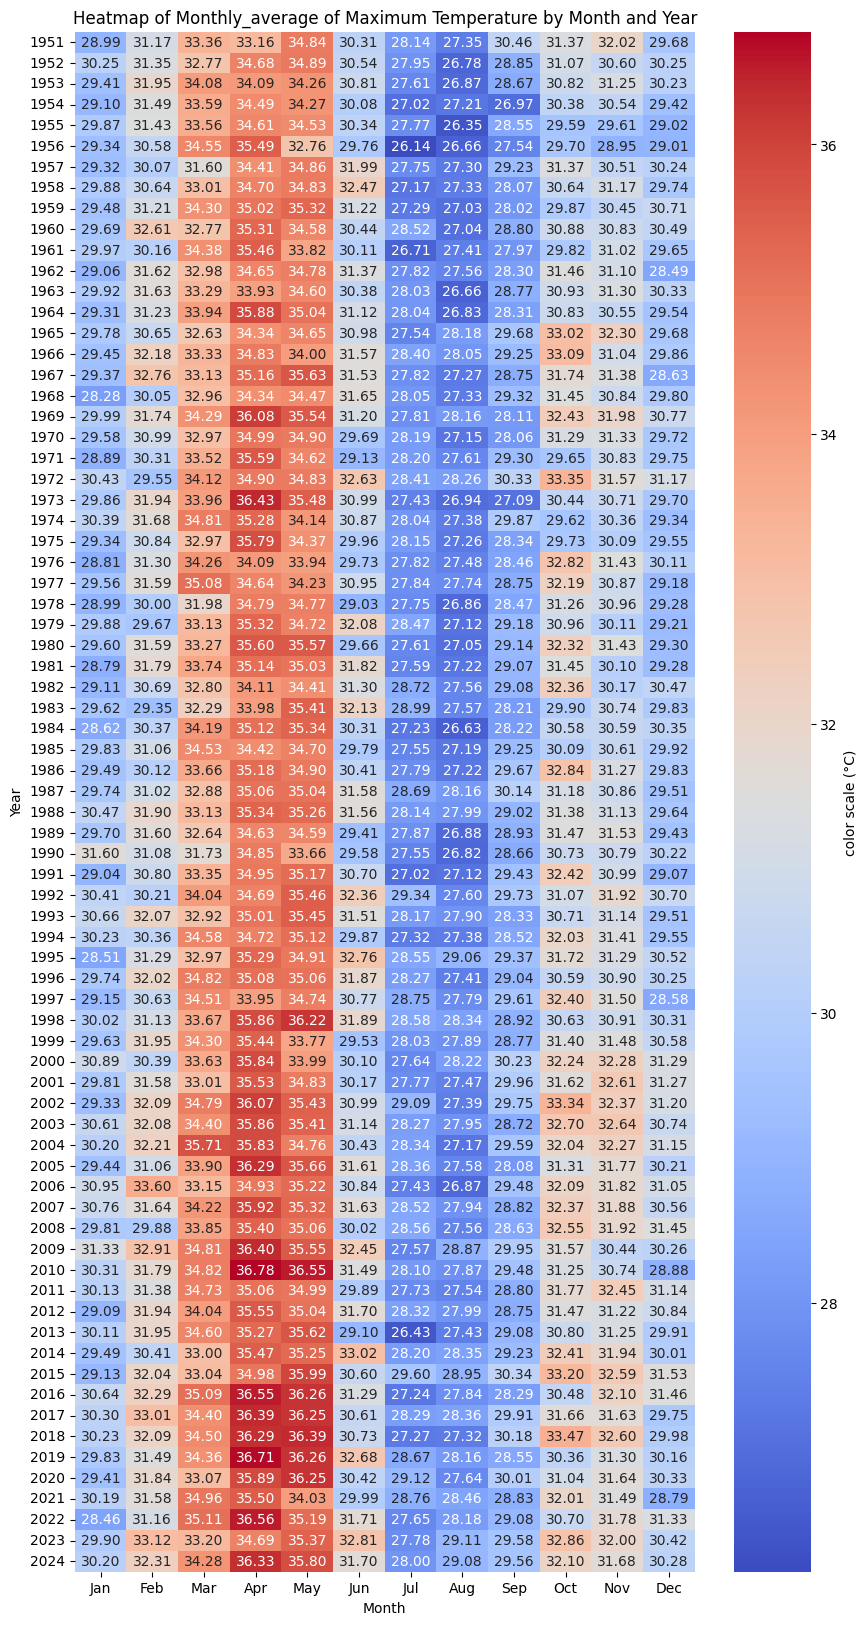

In [18]:
monthly_tmax = tmax.resample('ME').mean()
monthly_tmax['Year'] = monthly_tmax.index.year
monthly_tmax['Month'] = monthly_tmax.index.month

# Pivot the data to create a matrix for the heatmap
heatmap_data = monthly_tmax.pivot(index="Year", columns="Month", values="tmax")

# Plot the heatmap
plt.figure(figsize=(10, 20))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'color scale (°C)'})
plt.title('Heatmap of Monthly_average of Maximum Temperature by Month and Year')

# Set x-axis labels to month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticklabels(month_names)

plt.xlabel('Month')
plt.ylabel('Year')
plt.yticks(rotation=0)
plt.show()

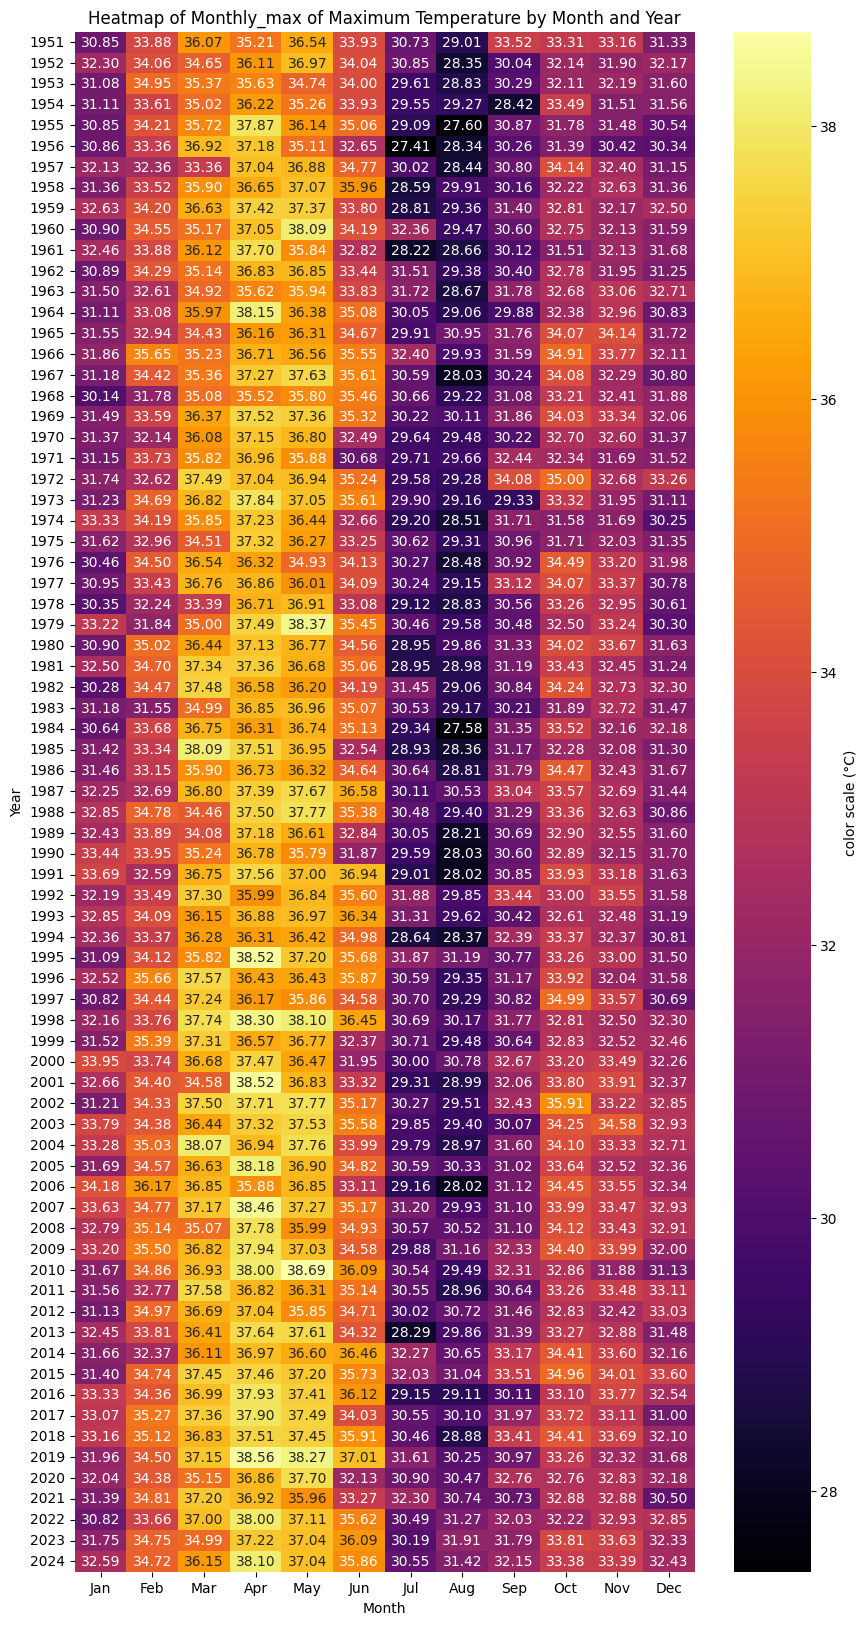

In [19]:
monthly_tmax = tmax.resample('ME').max()
monthly_tmax['Year'] = monthly_tmax.index.year
monthly_tmax['Month'] = monthly_tmax.index.month

# Pivot the data to create a matrix for the heatmap
heatmap_data = monthly_tmax.pivot(index="Year", columns="Month", values="tmax")

# Plot the heatmap
plt.figure(figsize=(10, 20))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="inferno", cbar_kws={'label': 'color scale (°C)'})
plt.title('Heatmap of Monthly_max of Maximum Temperature by Month and Year')

# Set x-axis labels to month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticklabels(month_names)

plt.xlabel('Month')
plt.ylabel('Year')
plt.yticks(rotation=0)
plt.show()

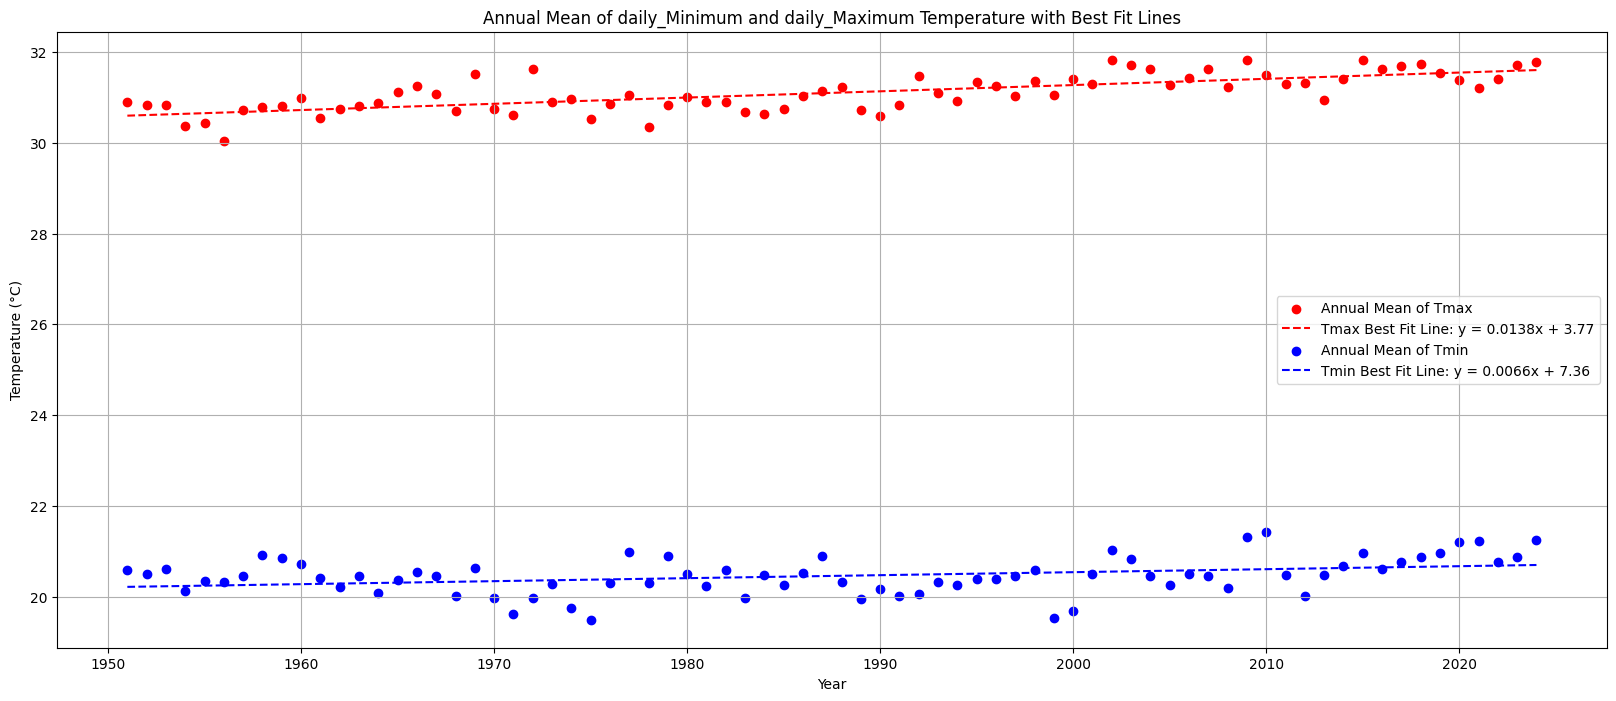

Equation of the best fit line for Tmax: y = 0.0138x + 3.77
Equation of the best fit line for Tmin: y = 0.0066x + 7.36


In [20]:
annual_mean_tmax = tmax.resample('YE').mean()
annual_mean_tmin = tmin.resample('YE').mean()

# Extract the years and tmin/tmax values
years = annual_mean_tmin.index.year
tmin_values = annual_mean_tmin['tmin'].values
tmax_values = annual_mean_tmax['tmax'].values

# Perform linear regression to find the best fit line for tmin
coefficients_tmin = np.polyfit(years, tmin_values, 1)
slope_tmin, intercept_tmin = coefficients_tmin
best_fit_line_tmin = slope_tmin * years + intercept_tmin

# Perform linear regression to find the best fit line for tmax
coefficients_tmax = np.polyfit(years, tmax_values, 1)
slope_tmax, intercept_tmax = coefficients_tmax
best_fit_line_tmax = slope_tmax * years + intercept_tmax

# Plot the data and the best fit lines
plt.figure(figsize=(20, 8))
plt.scatter(years, tmax_values, color='red', label='Annual Mean of Tmax')
plt.plot(years, best_fit_line_tmax, color='red', linestyle='--', label=f'Tmax Best Fit Line: y = {slope_tmax:.4f}x + {intercept_tmax:.2f}')
plt.scatter(years, tmin_values, color='blue', label='Annual Mean of Tmin')
plt.plot(years, best_fit_line_tmin, color='blue', linestyle='--', label=f'Tmin Best Fit Line: y = {slope_tmin:.4f}x + {intercept_tmin:.2f}')
plt.title('Annual Mean of daily_Minimum and daily_Maximum Temperature with Best Fit Lines')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

# Print the equations of the best fit lines
print(f"Equation of the best fit line for Tmax: y = {slope_tmax:.4f}x + {intercept_tmax:.2f}")
print(f"Equation of the best fit line for Tmin: y = {slope_tmin:.4f}x + {intercept_tmin:.2f}")

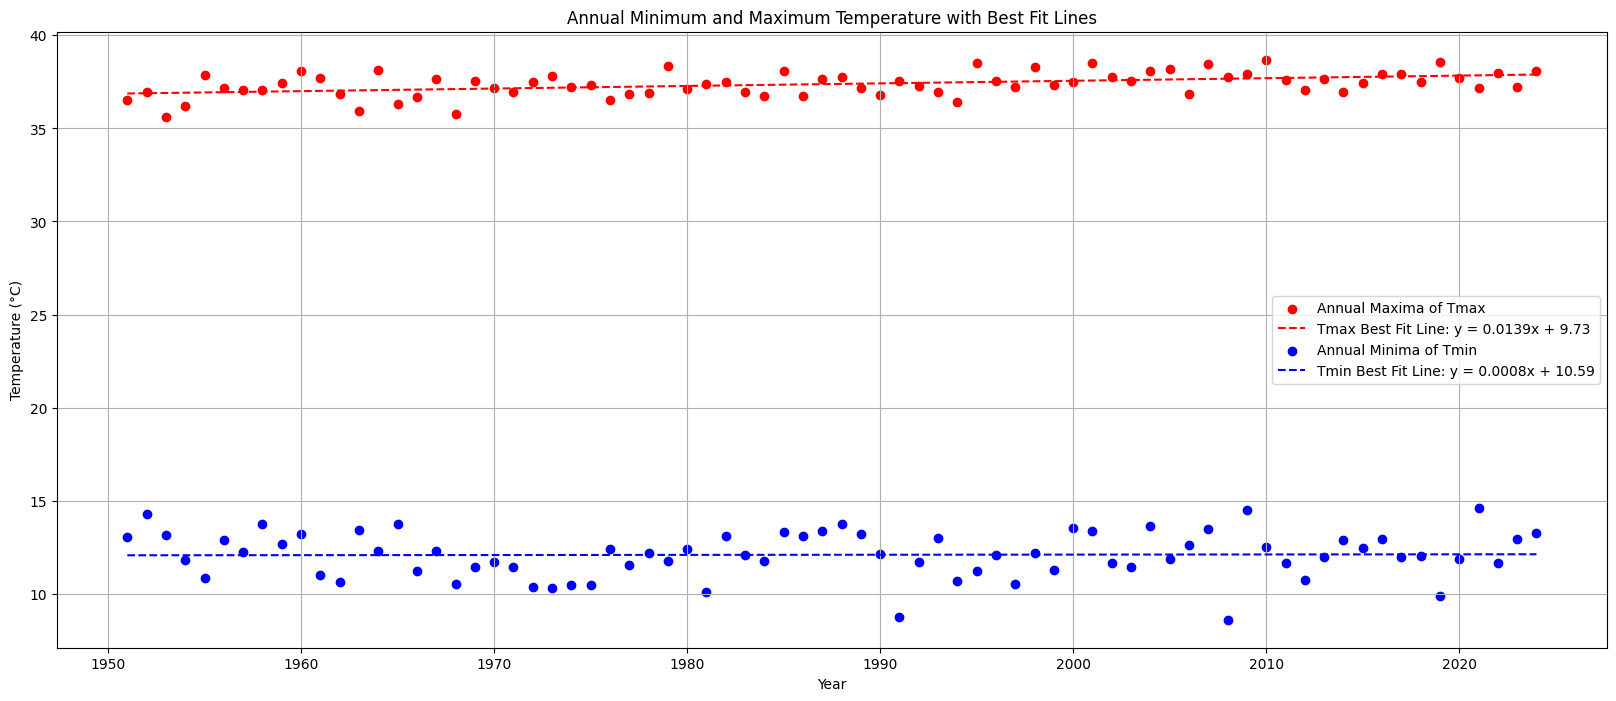

Equation of the best fit line for Tmax: y = 0.0139x + 9.73
Equation of the best fit line for Tmin: y = 0.0008x + 10.59


In [21]:
annual_mean_tmax = tmax.resample('YE').max()
annual_mean_tmin = tmin.resample('YE').min()

# Extract the years and tmin/tmax values
years = annual_mean_tmin.index.year
tmin_values = annual_mean_tmin['tmin'].values
tmax_values = annual_mean_tmax['tmax'].values

# Perform linear regression to find the best fit line for tmin
coefficients_tmin = np.polyfit(years, tmin_values, 1)
slope_tmin, intercept_tmin = coefficients_tmin
best_fit_line_tmin = slope_tmin * years + intercept_tmin

# Perform linear regression to find the best fit line for tmax
coefficients_tmax = np.polyfit(years, tmax_values, 1)
slope_tmax, intercept_tmax = coefficients_tmax
best_fit_line_tmax = slope_tmax * years + intercept_tmax

# Plot the data and the best fit lines
plt.figure(figsize=(20, 8))
plt.scatter(years, tmax_values, color='red', label='Annual Maxima of Tmax')
plt.plot(years, best_fit_line_tmax, color='red', linestyle='--', label=f'Tmax Best Fit Line: y = {slope_tmax:.4f}x + {intercept_tmax:.2f}')
plt.scatter(years, tmin_values, color='blue', label='Annual Minima of Tmin')
plt.plot(years, best_fit_line_tmin, color='blue', linestyle='--', label=f'Tmin Best Fit Line: y = {slope_tmin:.4f}x + {intercept_tmin:.2f}')
plt.title('Annual Minimum and Maximum Temperature with Best Fit Lines')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

# Print the equations of the best fit lines
print(f"Equation of the best fit line for Tmax: y = {slope_tmax:.4f}x + {intercept_tmax:.2f}")
print(f"Equation of the best fit line for Tmin: y = {slope_tmin:.4f}x + {intercept_tmin:.2f}")

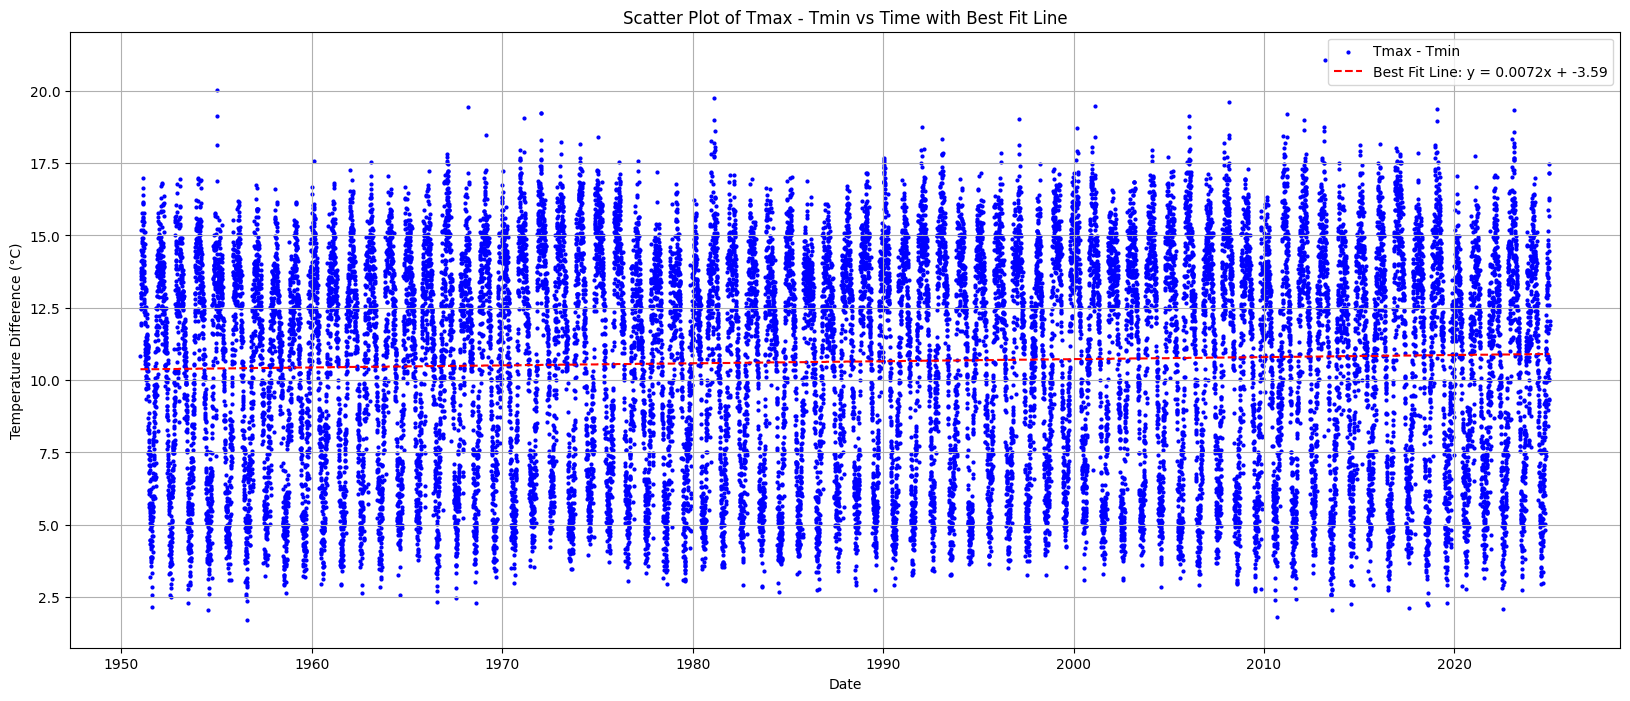

Equation of the best fit line: y = 0.0072x + -3.59


In [22]:
df['tmax_tmin_diff'] = df['tmax'] - df['tmin']

# Extract the years and the temperature differences
years = df.index.year
temp_diff = df['tmax_tmin_diff']

# Perform linear regression to find the best fit line for the temperature difference
coefficients_diff = np.polyfit(years, temp_diff, 1)
slope_diff, intercept_diff = coefficients_diff
best_fit_line_diff = slope_diff * years + intercept_diff

# Plot the scatter plot and the best fit line
plt.figure(figsize=(20, 8))
plt.scatter(df.index, temp_diff, color='blue', label='Tmax - Tmin', s = 4)
plt.plot(df.index, best_fit_line_diff, color='red', linestyle='--', label=f'Best Fit Line: y = {slope_diff:.4f}x + {intercept_diff:.2f}')
plt.title('Scatter Plot of Tmax - Tmin vs Time with Best Fit Line')
plt.xlabel('Date')
plt.ylabel('Temperature Difference (°C)')
plt.legend()
plt.grid(True)
plt.show()

# Print the equation of the best fit line
print(f"Equation of the best fit line: y = {slope_diff:.4f}x + {intercept_diff:.2f}")

# Analysis of Rainfall

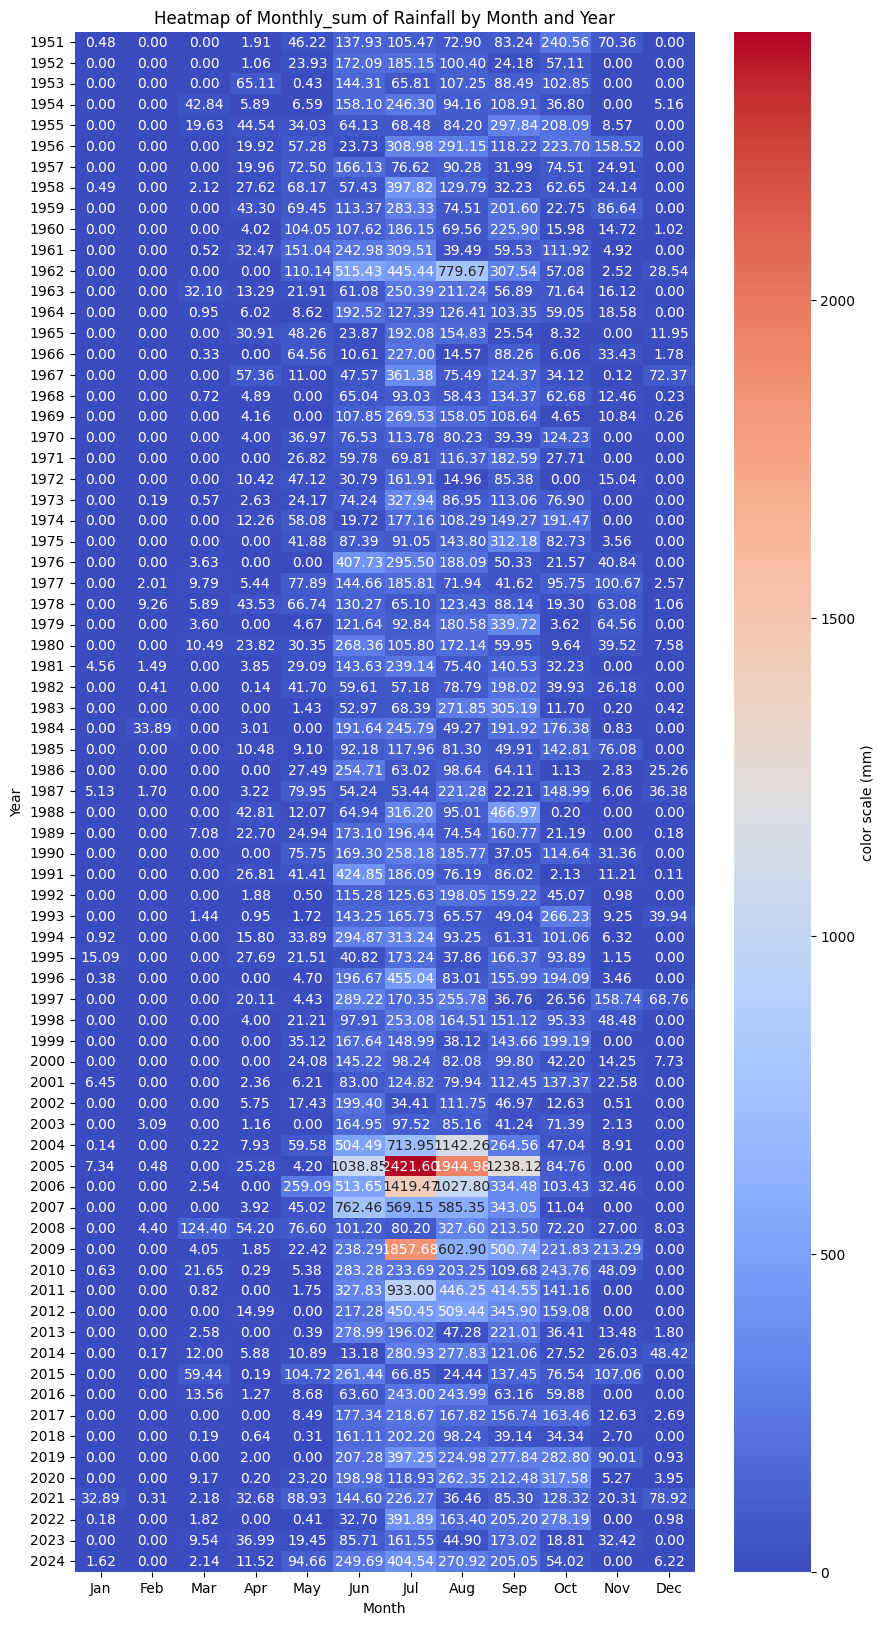

In [23]:
monthly_rain = rain.resample('ME').sum()
monthly_rain['Year'] = monthly_rain.index.year
monthly_rain['Month'] = monthly_rain.index.month

# Pivot the data to create a matrix for the heatmap
heatmap_data = monthly_rain.pivot(index="Year", columns="Month", values="rain")

# Plot the heatmap
plt.figure(figsize=(10, 20))
ax = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'color scale (mm)'})
plt.title('Heatmap of Monthly_sum of Rainfall by Month and Year')

# Set x-axis labels to month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticklabels(month_names)

plt.xlabel('Month')
plt.ylabel('Year')
plt.yticks(rotation=0)
plt.show()

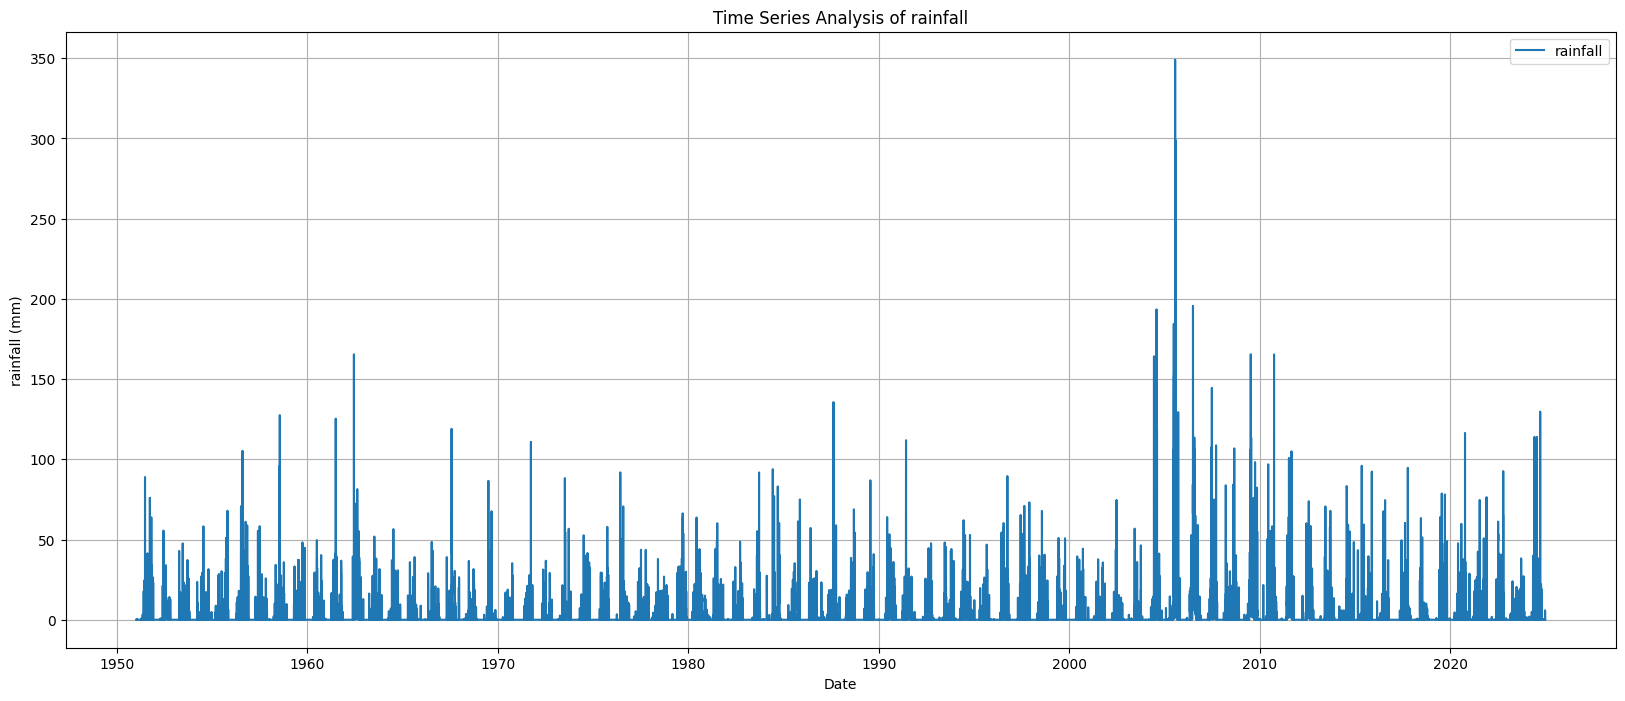

In [24]:
plt.figure(figsize=(20, 8))
plt.plot(rain.index, rain['rain'], label='rainfall')
plt.title('Time Series Analysis of rainfall')
plt.xlabel('Date')
plt.ylabel('rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

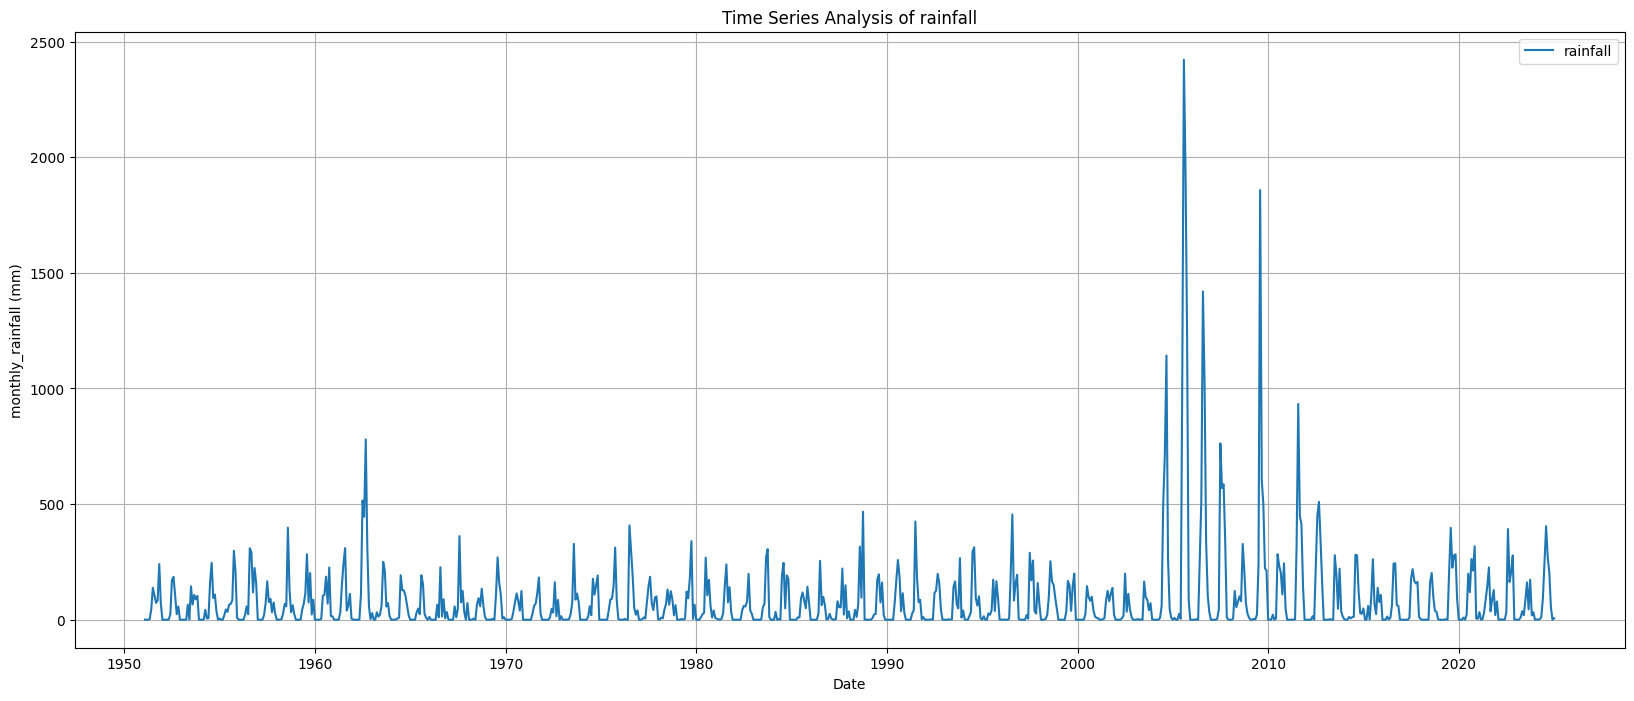

In [25]:
plt.figure(figsize=(20, 8))
monthly_rain = rain.resample('ME').sum()
plt.plot(monthly_rain.index, monthly_rain['rain'], label='rainfall')
plt.title('Time Series Analysis of rainfall')
plt.xlabel('Date')
plt.ylabel('monthly_rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

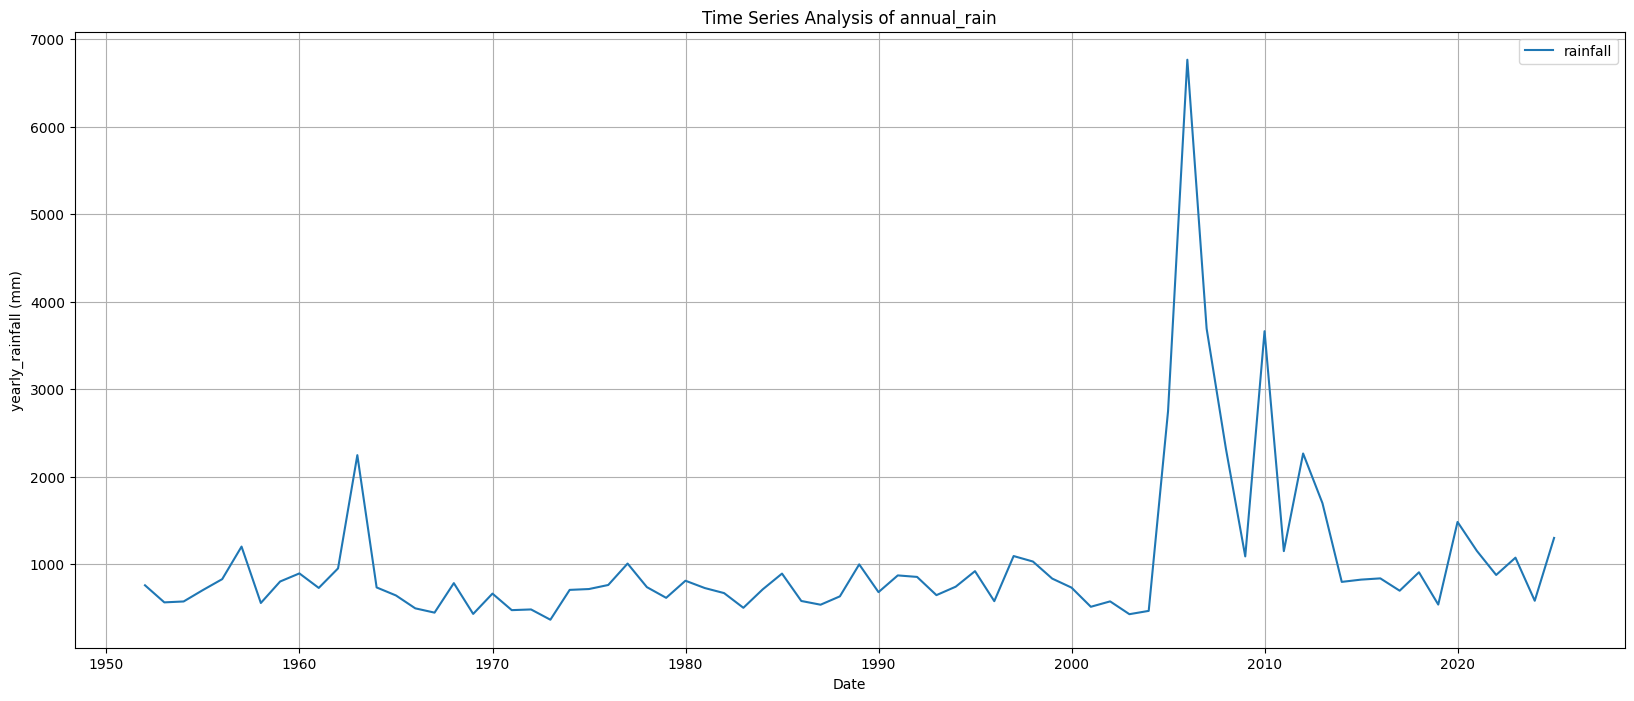

In [26]:
plt.figure(figsize=(20, 8))
annual_rain = rain.resample('YE').sum()
plt.plot(annual_rain.index, annual_rain['rain'], label='rainfall')
plt.title('Time Series Analysis of annual_rain')
plt.xlabel('Date')
plt.ylabel('yearly_rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
#yearly_rain.tail(10)

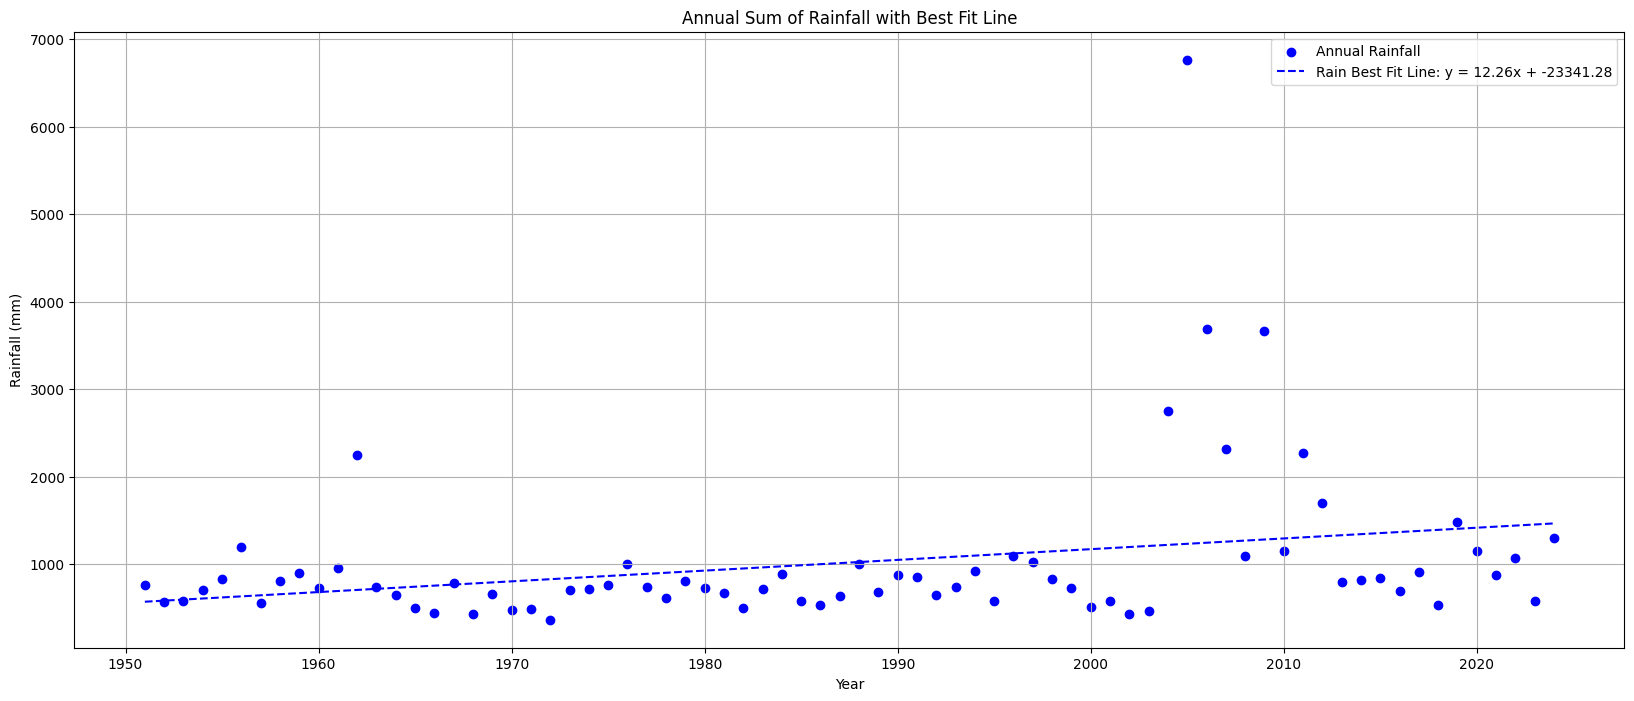

Equation of the best fit line for Rain: y = 12.26x + -23341.28


In [28]:
annual_sum = rain.resample('YE').sum()
# Extract the years and rainfall values
years = annual_sum.index.year
annual_rain = annual_sum['rain'].values

# Perform linear regression to find the best fit line for rainfall
coefficients_rain = np.polyfit(years, annual_rain, 1)
slope_rain, intercept_rain = coefficients_rain
best_fit_line_rain = slope_rain * years + intercept_rain

# Plot the data and the best fit lines
plt.figure(figsize=(20, 8))
plt.scatter(years, annual_rain, color='blue', label='Annual Rainfall')
plt.plot(years, best_fit_line_rain, color='blue', linestyle='--', label=f'Rain Best Fit Line: y = {slope_rain:.2f}x + {intercept_rain:.2f}')
plt.title('Annual Sum of Rainfall with Best Fit Line')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

# Print the equation of the best fit line
print(f"Equation of the best fit line for Rain: y = {slope_rain:.2f}x + {intercept_rain:.2f}")

# Temperature Forecast

In [32]:
from prophet import Prophet  # Facebook(Meta) Prophet model
import logging
# Suppress informational messages from cmdstanpy
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

In [33]:
# tmin

file_dir='co_test'
data_tmin.to_csv('coordinate_tmin.csv', lat, lon, file_dir)  # This downloads the file

# Construct the filename based on latitude and longitude
file_name = f'coordinate_tmin_{lat:.2f}_{lon:.2f}.csv'
    
# Read the temperature data from the file
tmin = pd.read_csv(f'{file_dir}/{file_name}')
    
# Convert the 'DateTime' column to a DatetimeIndex
tmin['DateTime'] = pd.to_datetime(tmin['DateTime'])
    
# Use the lat/lon combination for the correct column name in the CSV
col_name = f'{lat} {lon}'
    
# Create a DataFrame with DateTime as index and temperature as 'temp' column
tmin = pd.DataFrame(list(tmin[col_name]), index=tmin['DateTime'], columns=['tmin'])


# tmax

file_dir='co_test'
data_tmax.to_csv('coordinate_tmax.csv', lat, lon, file_dir)  # This downloads the file

# Construct the filename based on latitude and longitude
file_name = f'coordinate_tmax_{lat:.2f}_{lon:.2f}.csv'
    
# Read the temperature data from the file
tmax = pd.read_csv(f'{file_dir}/{file_name}')
    
# Convert the 'DateTime' column to a DatetimeIndex
tmax['DateTime'] = pd.to_datetime(tmax['DateTime'])
    
# Use the lat/lon combination for the correct column name in the CSV
col_name = f'{lat} {lon}'
    
# Create a DataFrame with DateTime as index and maximum temperature of day as 'tmax' column
tmax = pd.DataFrame(list(tmax[col_name]), index=tmax['DateTime'], columns=['tmax'])


# rain

file_dir='co_test'
data_rain.to_csv('coordinate_rain.csv', lat, lon, file_dir)  # This downloads the file

# Construct the filename based on latitude and longitude
file_name = f'coordinate_rain_{lat:.2f}_{lon:.2f}.csv'
    
# Read the temperature data from the file
rain = pd.read_csv(f'{file_dir}/{file_name}')
    
# Convert the 'DateTime' column to a DatetimeIndex
rain['DateTime'] = pd.to_datetime(rain['DateTime'])
    
# Use the lat/lon combination for the correct column name in the CSV
col_name = f'{lat} {lon}'
    
# Create a DataFrame with DateTime as index and rain of a day as 'rain' column
rain = pd.DataFrame(list(rain[col_name]), index=rain['DateTime'], columns=['rain'])


# merge all data(tmin, tmax, rain) of given assine lat & lon
df = pd.concat([tmin, tmax, rain], axis=1)
df

,tmin,tmax,rain
DateTime,,,
1951-01-01,17.2500,28.0900,0.0000
1951-01-02,16.7200,28.6300,0.0000
1951-01-03,15.4700,29.1600,0.0000
1951-01-04,15.4300,29.0200,0.0000
1951-01-05,15.0100,28.7700,0.0000
...,...,...,...
2024-12-27,19.5976,28.9455,0.0000
2024-12-28,19.9826,29.9912,0.0000
2024-12-29,19.7765,30.4973,5.8349


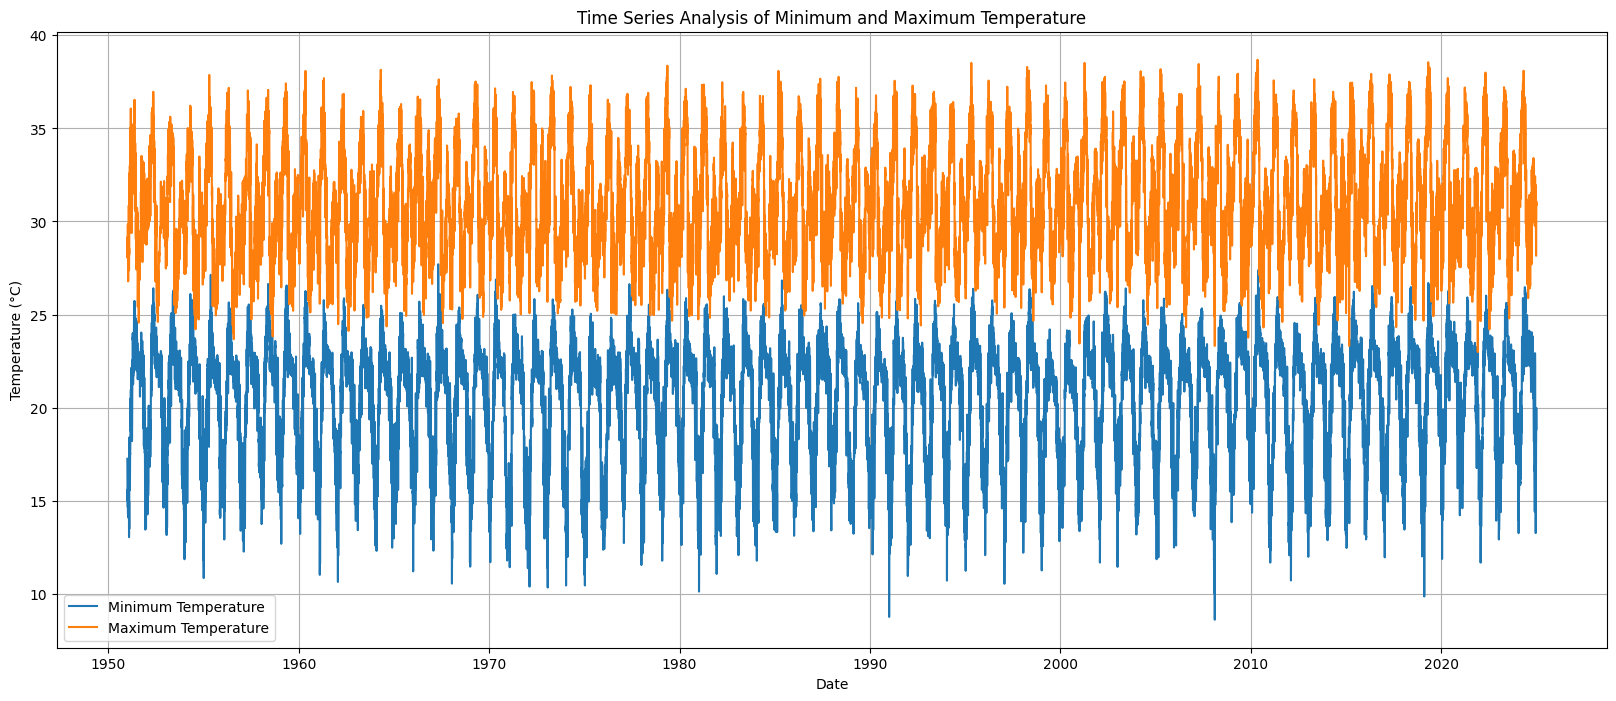

In [34]:
# Temp
plt.figure(figsize=(20, 8))
plt.plot(tmin.index, tmin['tmin'], label='Minimum Temperature')
plt.plot(tmax.index, tmax['tmax'], label='Maximum Temperature')
plt.title('Time Series Analysis of Minimum and Maximum Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

16:56:03 - cmdstanpy - INFO - Chain [1] start processing
16:56:05 - cmdstanpy - INFO - Chain [1] done processing


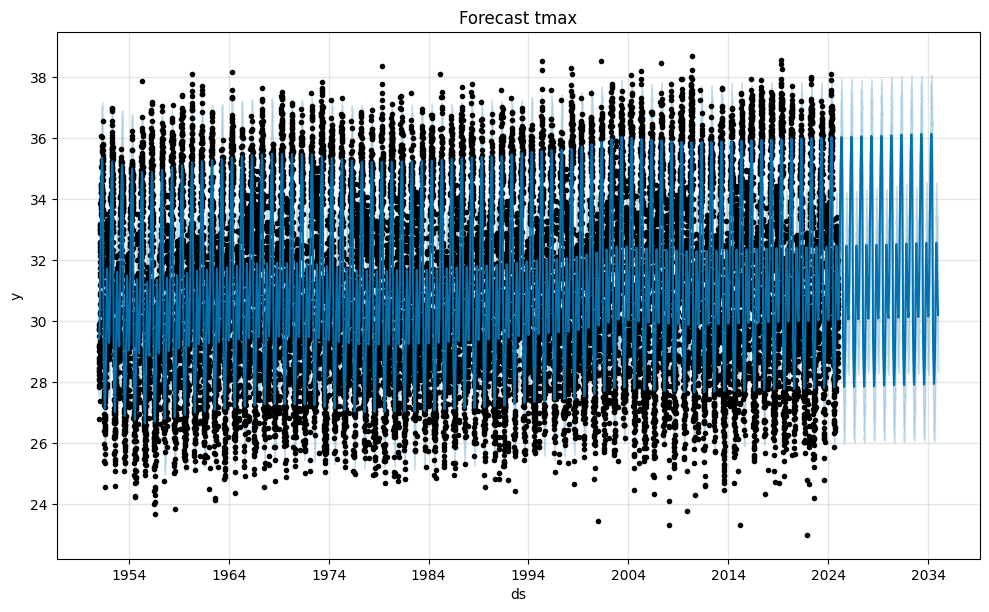

16:56:09 - cmdstanpy - INFO - Chain [1] start processing
16:56:13 - cmdstanpy - INFO - Chain [1] done processing


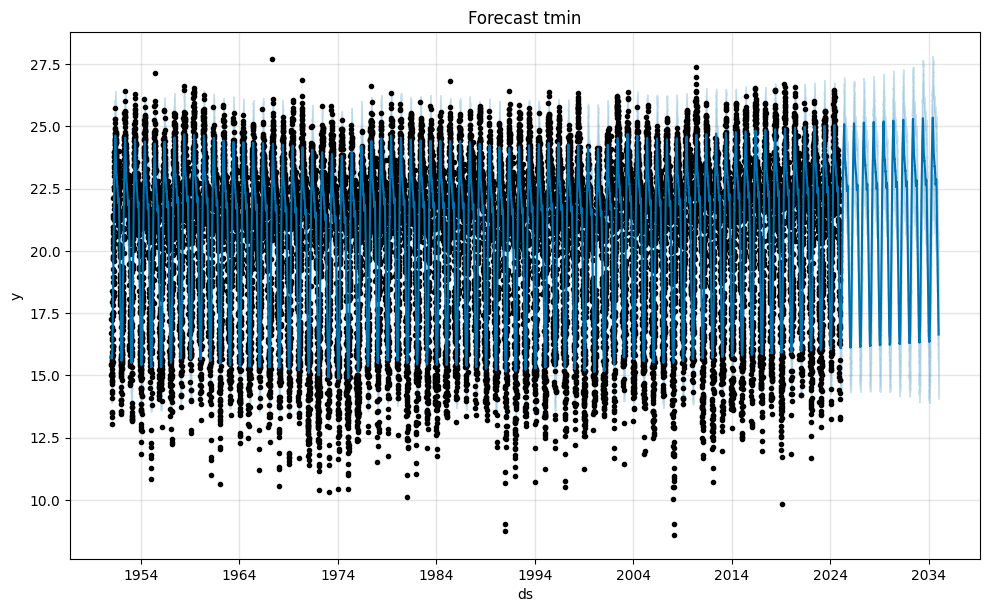

In [35]:
# Convert the tmax data into Prophet's expected format
df_tmax = tmax.reset_index()
df_tmax.columns = ['ds', 'y']  # Prophet requires 'ds' (date) and 'y' (value)

# Initialize and fit the Prophet model for tmax
model_tmax = Prophet()
model_tmax.fit(df_tmax)

# Create a dataframe for future dates (one more year)
future_dates_tmax = model_tmax.make_future_dataframe(periods=365*10, freq='D')

# Make predictions for tmax
forecast_tmax = model_tmax.predict(future_dates_tmax)

# Extract relevant columns for tmax
predicted_tmax = forecast_tmax[['ds', 'yhat']]
predicted_tmax.columns = ['Date', 'Predicted_Tmax']

# Filter the predictions for the next year (2025 to 2026)
predicted_tmax_next_year = predicted_tmax[predicted_tmax['Date'] > '2024-12-31']

# Display the predictions for tmax
# print(predicted_tmax_next_year)

# Plot the forecast for tmax
model_tmax.plot(forecast_tmax)
plt.title('Forecast tmax')
plt.show()




# Convert the tmin data into Prophet's expected format
df_tmin = tmin.reset_index()
df_tmin.columns = ['ds', 'y']  # Prophet requires 'ds' (date) and 'y' (value)

# Initialize and fit the Prophet model for tmin
model_tmin = Prophet()
model_tmin.fit(df_tmin)

# Create a dataframe for future dates (one more year)
future_dates_tmin = model_tmin.make_future_dataframe(periods=365*10, freq='D')

# Make predictions for tmin
forecast_tmin = model_tmin.predict(future_dates_tmin)

# Extract relevant columns for tmin
predicted_tmin = forecast_tmin[['ds', 'yhat']]
predicted_tmin.columns = ['Date', 'Predicted_Tmin']

# Filter the predictions for the next year (2025 to 2026)
predicted_tmin_next_year = predicted_tmin[predicted_tmin['Date'] > '2024-12-31']

# Display the predictions for tmin
# print(predicted_tmin_next_year)

# Plot the forecast for tmin
model_tmin.plot(forecast_tmin)
plt.title('Forecast tmin')
plt.show()

In [36]:
predicted_tmax_next_year.set_index('Date', inplace=True)
predicted_tmin_next_year.set_index('Date', inplace=True)

# Rename columns
predicted_tmax_next_year.columns = ['tmax']
predicted_tmin_next_year.columns = ['tmin']

# Display the DataFrames to verify
print(predicted_tmax_next_year)
print(predicted_tmin_next_year)

                 tmax
Date                 
2025-01-01  30.066696
2025-01-02  30.055203
2025-01-03  30.032313
2025-01-04  30.052621
2025-01-05  30.049342
...               ...
2034-12-25  30.297071
2034-12-26  30.271002
2034-12-27  30.253748
2034-12-28  30.228579
2034-12-29  30.192472

[3650 rows x 1 columns]
                 tmin
Date                 
2025-01-01  16.243392
2025-01-02  16.216717
2025-01-03  16.189482
2025-01-04  16.159188
2025-01-05  16.155798
...               ...
2034-12-25  16.809296
2034-12-26  16.782095
2034-12-27  16.735009
2034-12-28  16.687048
2034-12-29  16.639187

[3650 rows x 1 columns]


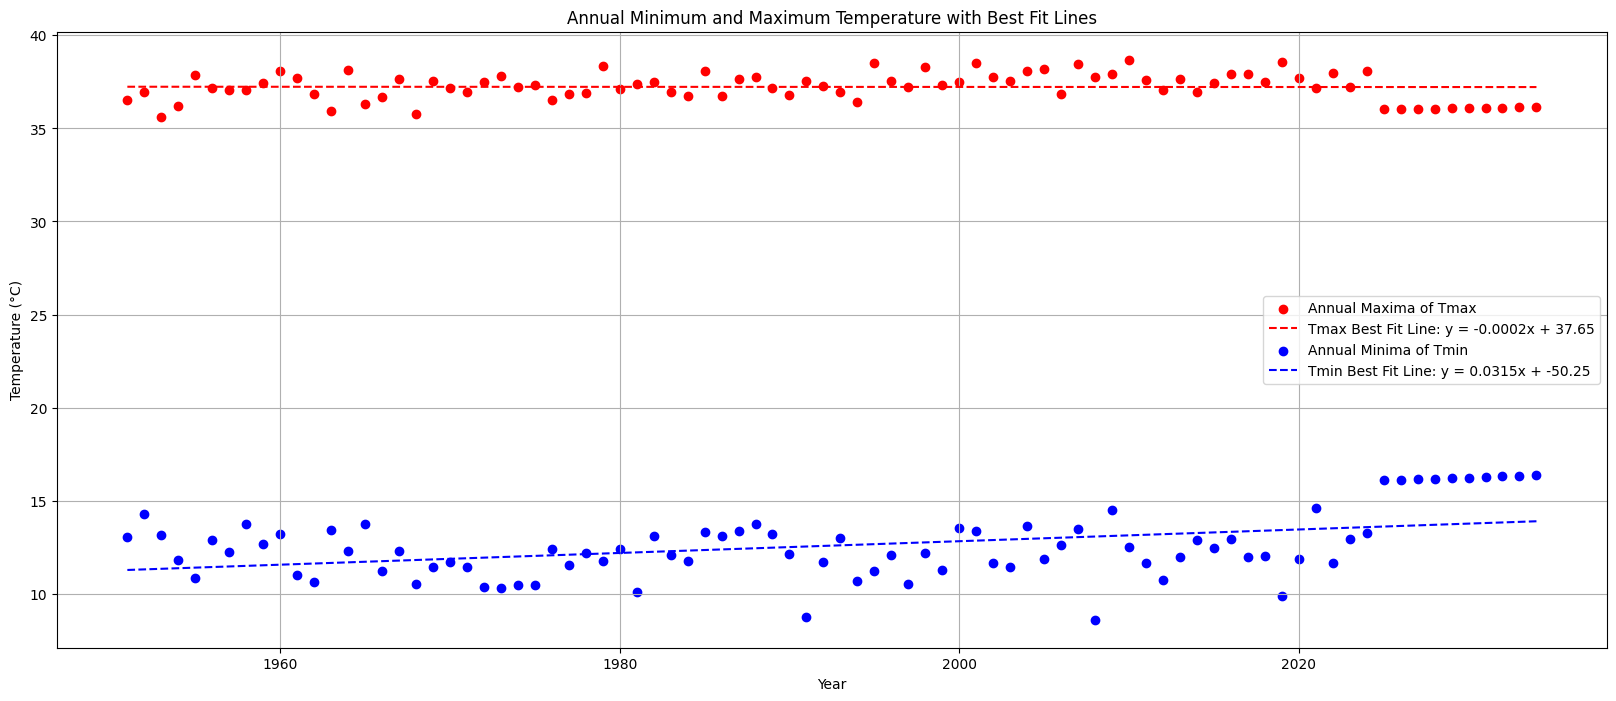

Equation of the best fit line for Tmax: y = -0.0002x + 37.65
Equation of the best fit line for Tmin: y = 0.0315x + -50.25


In [37]:
tmax = pd.concat([tmax, predicted_tmax_next_year])
tmin = pd.concat([tmin, predicted_tmin_next_year])


# annual_mean_tmax = predicted_tmax.resample('YE').max()
# annual_mean_tmin = predicted_tmin.resample('YE').min()

annual_mean_tmax = tmax.resample('YE').max()
annual_mean_tmin = tmin.resample('YE').min()

# Extract the years and tmin/tmax values
years = annual_mean_tmin.index.year
tmin_values = annual_mean_tmin['tmin'].values
tmax_values = annual_mean_tmax['tmax'].values

# Perform linear regression to find the best fit line for tmin
coefficients_tmin = np.polyfit(years, tmin_values, 1)
slope_tmin, intercept_tmin = coefficients_tmin
best_fit_line_tmin = slope_tmin * years + intercept_tmin

# Perform linear regression to find the best fit line for tmax
coefficients_tmax = np.polyfit(years, tmax_values, 1)
slope_tmax, intercept_tmax = coefficients_tmax
best_fit_line_tmax = slope_tmax * years + intercept_tmax

# Plot the data and the best fit lines
plt.figure(figsize=(20, 8))
plt.scatter(years, tmax_values, color='red', label='Annual Maxima of Tmax')
plt.plot(years, best_fit_line_tmax, color='red', linestyle='--', label=f'Tmax Best Fit Line: y = {slope_tmax:.4f}x + {intercept_tmax:.2f}')
plt.scatter(years, tmin_values, color='blue', label='Annual Minima of Tmin')
plt.plot(years, best_fit_line_tmin, color='blue', linestyle='--', label=f'Tmin Best Fit Line: y = {slope_tmin:.4f}x + {intercept_tmin:.2f}')
plt.title('Annual Minimum and Maximum Temperature with Best Fit Lines')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

# Print the equations of the best fit lines
print(f"Equation of the best fit line for Tmax: y = {slope_tmax:.4f}x + {intercept_tmax:.2f}")
print(f"Equation of the best fit line for Tmin: y = {slope_tmin:.4f}x + {intercept_tmin:.2f}")

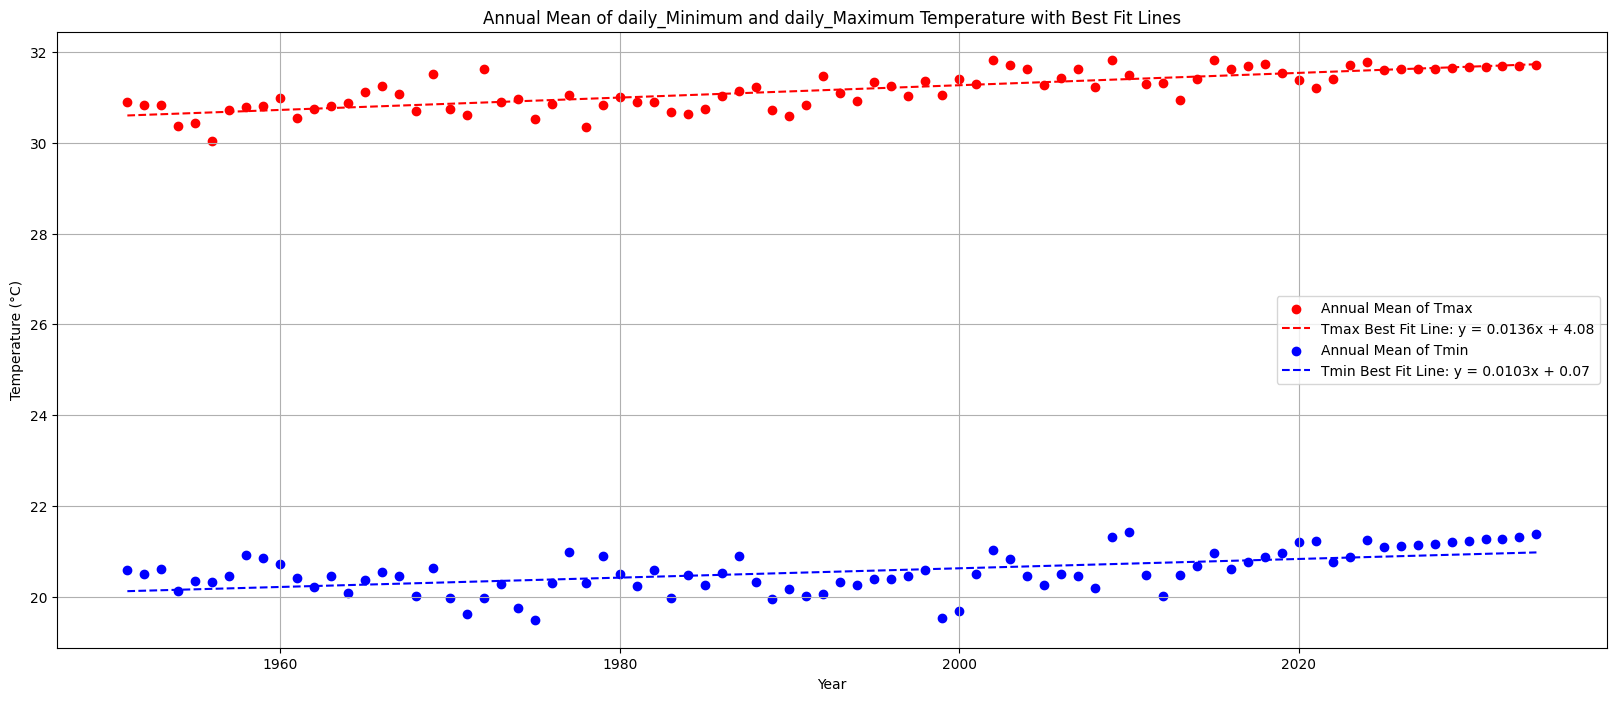

Equation of the best fit line for Tmax: y = 0.0136x + 4.08
Equation of the best fit line for Tmin: y = 0.0103x + 0.07


In [38]:
annual_mean_tmax = tmax.resample('YE').mean()
annual_mean_tmin = tmin.resample('YE').mean()

# Extract the years and tmin/tmax values
years = annual_mean_tmin.index.year
tmin_values = annual_mean_tmin['tmin'].values
tmax_values = annual_mean_tmax['tmax'].values

# Perform linear regression to find the best fit line for tmin
coefficients_tmin = np.polyfit(years, tmin_values, 1)
slope_tmin, intercept_tmin = coefficients_tmin
best_fit_line_tmin = slope_tmin * years + intercept_tmin

# Perform linear regression to find the best fit line for tmax
coefficients_tmax = np.polyfit(years, tmax_values, 1)
slope_tmax, intercept_tmax = coefficients_tmax
best_fit_line_tmax = slope_tmax * years + intercept_tmax

# Plot the data and the best fit lines
plt.figure(figsize=(20, 8))
plt.scatter(years, tmax_values, color='red', label='Annual Mean of Tmax')
plt.plot(years, best_fit_line_tmax, color='red', linestyle='--', label=f'Tmax Best Fit Line: y = {slope_tmax:.4f}x + {intercept_tmax:.2f}')
plt.scatter(years, tmin_values, color='blue', label='Annual Mean of Tmin')
plt.plot(years, best_fit_line_tmin, color='blue', linestyle='--', label=f'Tmin Best Fit Line: y = {slope_tmin:.4f}x + {intercept_tmin:.2f}')
plt.title('Annual Mean of daily_Minimum and daily_Maximum Temperature with Best Fit Lines')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

# Print the equations of the best fit lines
print(f"Equation of the best fit line for Tmax: y = {slope_tmax:.4f}x + {intercept_tmax:.2f}")
print(f"Equation of the best fit line for Tmin: y = {slope_tmin:.4f}x + {intercept_tmin:.2f}")

# Rainfall Forecast

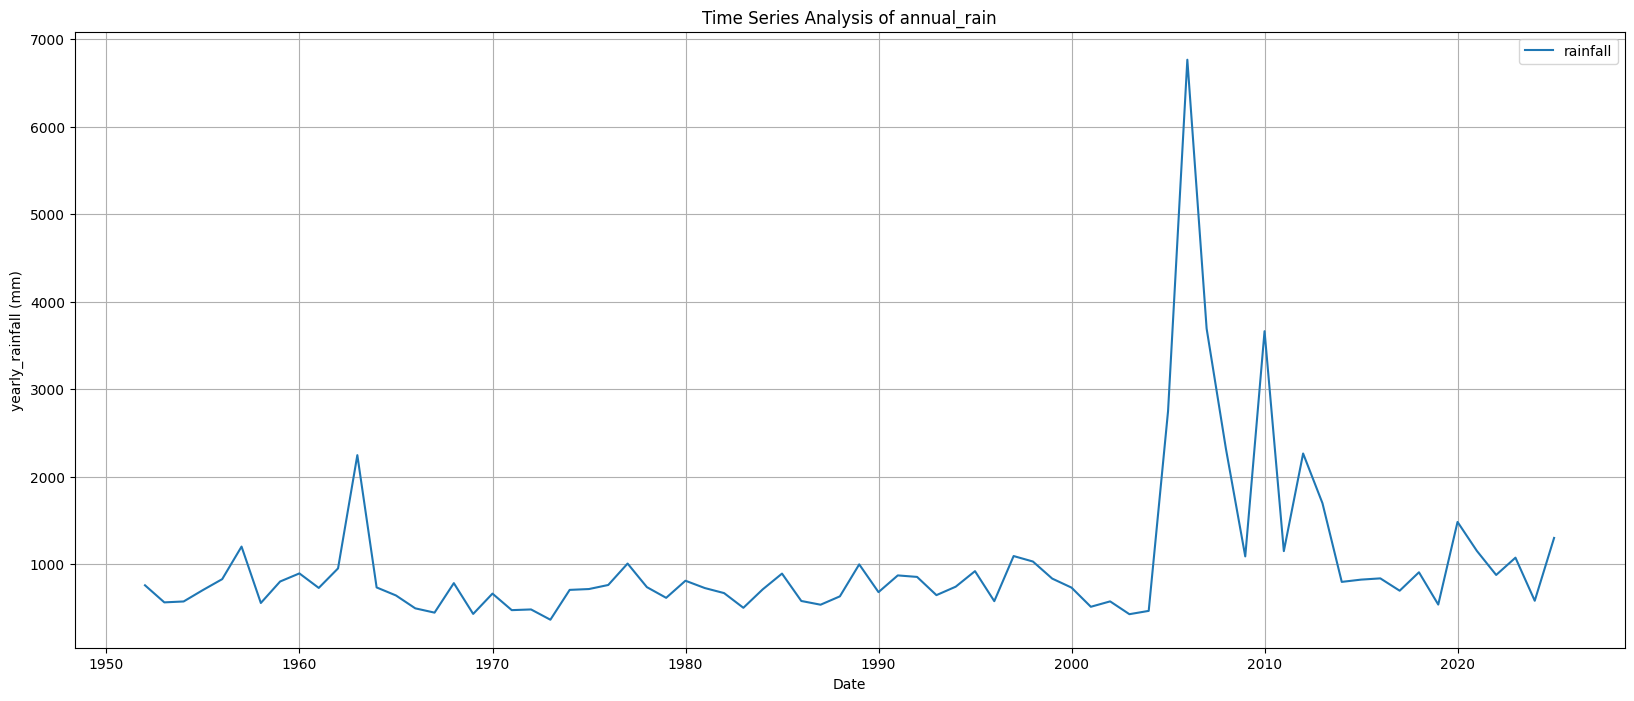

In [39]:
plt.figure(figsize=(20, 8))
annual_rain = rain.resample('YE').sum()
plt.plot(annual_rain.index, annual_rain['rain'], label='rainfall')
plt.title('Time Series Analysis of annual_rain')
plt.xlabel('Date')
plt.ylabel('yearly_rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

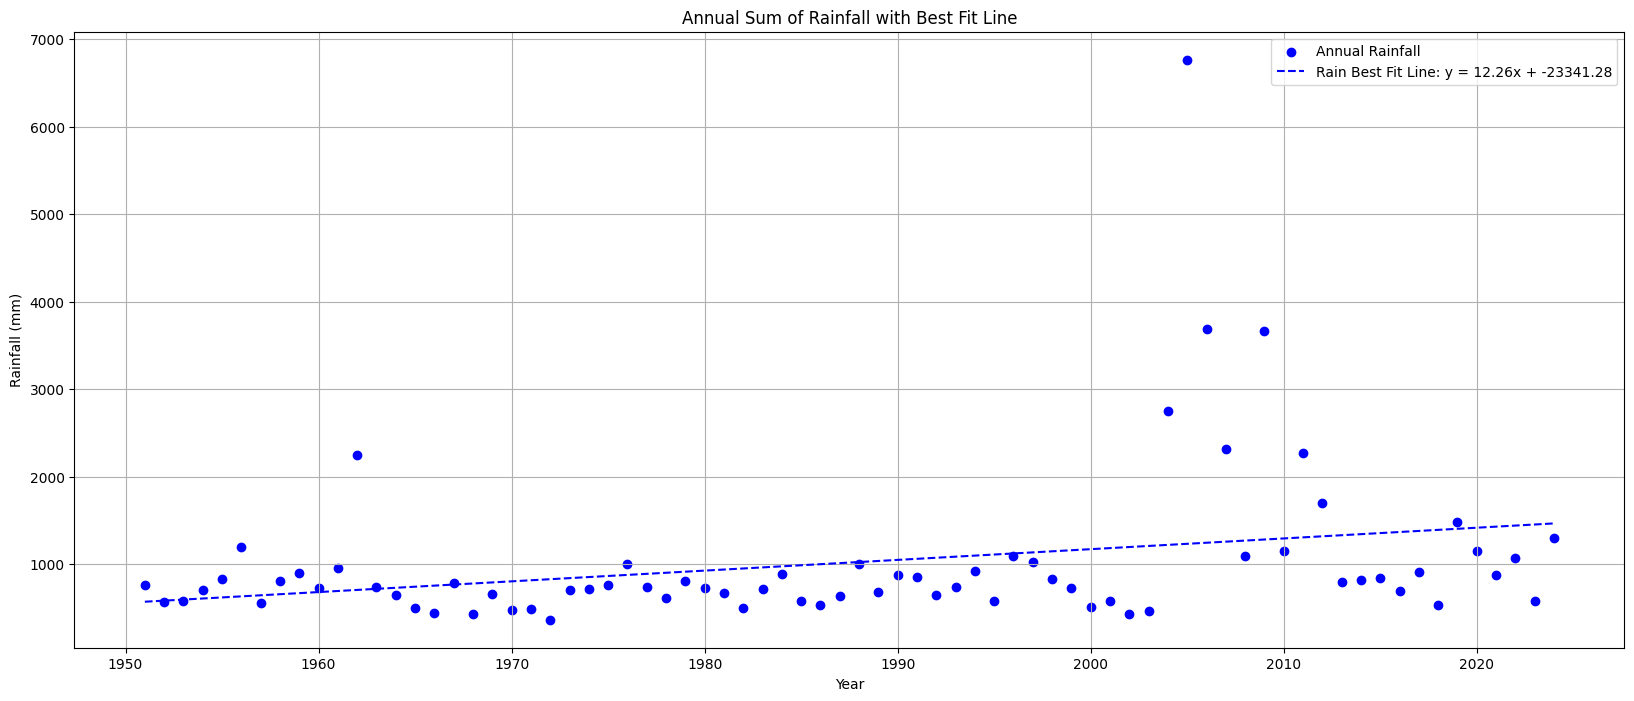

Equation of the best fit line for Rain: y = 12.26x + -23341.28


In [40]:
annual_sum = rain.resample('YE').sum()
# Extract the years and rainfall values
years = annual_sum.index.year
annual_rain = annual_sum['rain'].values

# Perform linear regression to find the best fit line for rainfall
coefficients_rain = np.polyfit(years, annual_rain, 1)
slope_rain, intercept_rain = coefficients_rain
best_fit_line_rain = slope_rain * years + intercept_rain

# Plot the data and the best fit lines
plt.figure(figsize=(20, 8))
plt.scatter(years, annual_rain, color='blue', label='Annual Rainfall')
plt.plot(years, best_fit_line_rain, color='blue', linestyle='--', label=f'Rain Best Fit Line: y = {slope_rain:.2f}x + {intercept_rain:.2f}')
plt.title('Annual Sum of Rainfall with Best Fit Line')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.show()

# Print the equation of the best fit line
print(f"Equation of the best fit line for Rain: y = {slope_rain:.2f}x + {intercept_rain:.2f}")

17:10:00 - cmdstanpy - INFO - Chain [1] start processing
17:10:00 - cmdstanpy - INFO - Chain [1] done processing


         Date  Predicted_Rain
0  1951-12-31      495.965514
1  1952-12-31      620.005477
2  1953-12-31      637.020821
3  1954-12-31      611.965706
4  1955-12-31      544.893463
..        ...             ...
95 2046-12-31     1737.309033
96 2047-12-31     1670.236796
97 2048-12-31     1794.276766
98 2049-12-31     1811.292117
99 2050-12-31     1786.237009

[100 rows x 2 columns]


Text(62.972222222222214, 0.5, 'Rainfall (mm)')

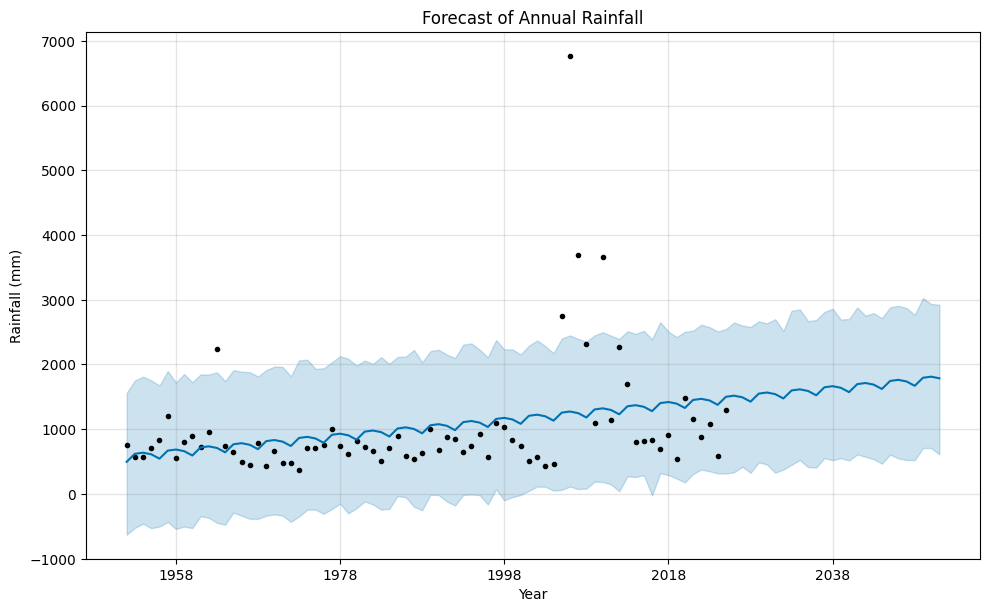

In [41]:
annual_sum = rain.resample('YE').sum()
# Convert the annual_sum data into Prophet's expected format
df_rain = annual_sum.reset_index()
df_rain.columns = ['ds', 'y']  # Prophet requires 'ds' (date) and 'y' (value)

# Initialize and fit the Prophet model for annual rain
model_rain = Prophet()
model_rain.fit(df_rain)

# Create a dataframe for future dates (next 2 years)
future_dates_rain = model_rain.make_future_dataframe(periods=26, freq='YE')

# Make predictions for annual rain
forecast_rain = model_rain.predict(future_dates_rain)

# Extract relevant columns for annual rain
predicted_rain = forecast_rain[['ds', 'yhat']]
predicted_rain.columns = ['Date', 'Predicted_Rain']

# Display the predictions for annual rain
print(predicted_rain)


# Plot the forecast for annual rain
model_rain.plot(forecast_rain)
plt.title('Forecast of Annual Rainfall')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')